**ML Based Harmful Meta post detector**

In [591]:
import pandas as pd
import numpy as np
import re
import math
import matplotlib.pyplot as plt
import seaborn as sns
from random import randint
from io import StringIO
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import nltk
from textblob import TextBlob

In [592]:
from textblob import TextBlob
from typing import List
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import joblib
from sklearn.base import BaseEstimator, TransformerMixin

In [593]:
# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')

1. **LOADING AND PREPARING DATA**

In [594]:
tig_df= pd.read_csv("/Users/a1234/meta_tigrinya_dataset_cleaned.csv")

In [595]:
tig_df.head(43)

,id,name,date,content,label,language,post_type,user_reported,action_taken,city
0,1.0,Biniam Girmay,2019-08-13,ነዚኦም አማ ብሓደ ጌርካ ምጉሓፎም አዩ ኔሩ,Harmful,Tigrinya,post,True,Removed,Mekelle
1,2.0,Almaz gual gere,2018-11-09,ደሓን ኩን ሓደ እተወላዊ ሰብ ናትካ ኣብ ሓበሬታ ኣለኹ,Neutral,Tigrinya,comment,False,none,Addis Ababa
2,3.0,Hagos Berhe,2018-04-29,ክሊቲኦም ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም ዝፍታሕ ውን አይመስለንን?,Harmful,Tigrinya,share,False,Warning,Asmera
3,4.0,Selam,2020-01-05,ሓበሬታ ለውጢ ሰላም ንምግባር ኣሎ,Neutral,Tigrinya,post,True,none,Adama
4,5.0,Fikerte,2020-12-05,ቡዳ፤ጠቢብ፤በላዕቲ ሰብ አዮም ኮ አሳቶም አይትፈልጥን ዲካ?,Harmful,Tigrinya,comment,False,Removed,Bahr dar
5,6.0,Mahari,2018-04-27,ትኳን ዝኮነ ህዝቢ ሰላም አይደልን?,Harmful,Tigrinya,post,True,Removed,Gonder
6,7.0,Feven,2021-02-23,ክብር ሰብ ሰብ የክብር,Neutral,Tigrinya,share,False,none,Shire
7,8.0,Biniam,2021-11-18,ይብል እንተዝኸውን ክንድን ይኹን ንጹር ቃላት ክንክብር,Neutral,Tigrinya,comment,False,none,Adigrat
8,9.0,Martha,2022-02-26,ክብርን ፍትሒን ንህዝቢ ኢትዮጵያ ክንተግበር,Neutral,Tigrinya,post,False,none,Abiy-Adi
9,10.0,Yohannes,2018-09-10,ኣይናውቕን ክትተሓልዩን ብማህበረሰብ እንታይ ክትግበሩ ክትብሉና,Neutral,Tigrinya,comment,True,none,Adwa


In [700]:
tig_df.columns

Index(['id', 'name', 'date', 'content', 'label', 'language', 'post_type',
       'user_reported', 'action_taken', 'city'],
      dtype='object')

In [596]:
#  Harmful Keywords 
context_markers = [
    "ደማት", "ነገራትኩም ግጉይን ሰይጣናውን ዩ", "ይተርፍ", "በሎ", "ምስንቱ ኣነ", "ድሮም አስኩም ዶ ዘይትረብሑ",
    "ምጉሓፎም", "ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም", "ቡዳ", "ጠቢብ", "በላዕቲ ሰብ አዮም",
    "ትኳን ዝኮነ ህዝቢ", "ደማዊ ጦርነት", "ዲቃላ", "ይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ",
    "ክርችሽኑ አዩ ዘለዎም", "ዘይሰብ", "ንሰብ ዘይመስል", "ቀታሊ አዩ",
    "ንህዝብና ቀተልቱ መራሕትና አዮም", "ናብ ውግእ", "ዘርኣዊ ፅንተት", "ኣምባገነንነት",
    "ዘቅትል ዘረሽንን", "ወረርቲ ሓይልታት ዝሞቱ", "ህበይ", "ወዓግ", "ተመን", "ጨምላቕ",
    "ግብረ እከይ", "ኢዚ ሰብ ዘይኮነ", "ነዚኦም ከመይ ኢልና ንሓዝነሎም", "ሰይጣን", "ቐታ", "ጦርነት",
    "ኩናት", "ውግእ", "ወዲ ሻርሙጣ", "ወዲ ዓጣሪት",
    "ፅናሕ ከርእየካ እየ ግዜኻ ተፀበ", "ሃይማኖትኩም ትክክለኛ ኣይኮነን", "አድጊ","ደማት", "ነገራትኩም ግጉይን ሰይጣናውን ዩ", "ይተርፍ", "በሎ", "ምስንቱ ኣነ", 
    "ድሮም አስኩም ዶ ዘይትረብሑ", "ምጉሓፎም", "ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም", 
    "ቡዳ", "ጠቢብ", "በላዕቲ ሰብ አዮም", "ትኳን ዝኮነ ህዝቢ", "ደማዊ ጦርነት", 
    "ዲቃላ", "ይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ", "ክርችሽኑ አዩ ዘለዎም", "ዘይሰብ", 
    "ንሰብ ዘይመስል", "ቀታሊ አዩ", "ንህዝብና ቀተልቱ መራሕትና አዮም", "ናብ ውግእ", 
    "ዘርኣዊ ፅንተት", "ኣምባገነንነት", "ዘቅትል ዘረሽንን", "ወረርቲ ሓይልታት ዝሞቱ", 
    "ህበይ", "ወዓግ", "ተመን", "ጨምላቕ", "ግብረ እከይ", "ኢዚ ሰብ ዘይኮነ", 
    "ነዚኦም ከመይ ኢልና ንሓዝነሎም", "ሰይጣን", "ቐታ", "ጦርነት", "ኩናት", "ውግእ", 
    "ወዲ ሻርሙጣ", "ወዲ ዓጣሪት", "ፅናሕ ከርእየካ እየ ግዜኻ ተፀበ", 
    "ሃይማኖትኩም ትክክለኛ ኣይኮነን", "አድጊ", "ዓሻ", "ጨዋም", "ኣራጊ", "ዘይብሉ", 
    "ደንጉዛ", "ጭራሽ", "ሓሰኻ", "ግድፍ", "ኣዝሒልካ", "በደል", "ውርጪ", "ኣይነብርካን", 
    "ከተማ ዘይብሉ", "ደኣ እምበር", "ኣይትኾንካ", "ጨፍጫፋ", "ኣይትግበር", 
    "ጨራሽ ወዲ", "ዘርኢ �ንጣ", "ኣይትጸግብ", "ባእዳዊ", "ኣረጋጋጽ", "ዘርኢ ኣረማዊ", 
    "ጨራሽ ኣይነበረትን", "ኣይትሓስብ", "ዓሻ ዝበሃል እዩ", "ኣይትንቀሳቀስ", 
    "ወዲ ሽምኩር", "እዚ ሰብ ዘይኮነ", "ኣይትግለጽ", "ኣይትነግር", "ጽልኢ", 
    "ኣይኮነን ሰብ", "ዘርኢ ገዛእቲ", "ኣረጋጋጽ ሕማም", "ኣይትሰማማዕ", 
    "ዘይትፈልጥ", "ኣይትበሃል", "ንህዝብና ቀተልቱ", "ኣንስተይቲ ኣይትኾንኪ", 
    "ንህዝብና ይበልዑ", "መራሕትና ኣረጋጋጽ እዮም", "እምነት ዘይብሎም", 
    "ጋውጋው", "ክርሽታን አዩ ዘለዎም"
]

**Before SPLIT DATA**

In [597]:
X = tig_df.drop(columns=["label"])
y = tig_df["label"]

#  Split into train and test (stratified, reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

**Combine X_train and y_train back into one DataFrame**

In [598]:
train_df = X_train.copy()
train_df["label"] = y_train
train_df.reset_index(drop=True, inplace=True)

test_df = X_test.copy()
test_df["label"] = y_test
test_df.reset_index(drop=True, inplace=True)

In [599]:
train_df.head()

,id,name,date,content,language,post_type,user_reported,action_taken,city,label
0,42.0,Micky Raya,2022-11-02,💛ፅሃየ ካሕሳይ (ጀብጀብ) ምስሊ ቑልዕነትን ገድሊን❤️\nተጋዳላይ ፀሃየ....,Tigrinya,comment,False,Warning,Toronto,Neutral
1,51.0,Getachew k Reda,NaN,ንረጋጋዕ ኣሓትን ኣሕዋትን,Tigrinya,status,False,none,Mekelle,Neutral
2,50.0,Dina mulu,NaN,ገርመና ኣሎ በለ ደራፊ,Tigrinya,replay,False,none,Mekelle,Neutral
3,61.0,Tsegazab,2021-05-07,ንብጹእ ወቅዱስ ኣቡነ ማትያስ ኣብ ዘርኣዊ ምጽናት ህዝቢ ትግራይ ኣመልኪቱ...,Tigrinya,post,True,Warning,Addis Ababa,Harmful
4,57.0,Wedi Hailu Adwa,NaN,ኣብ ኣክሱም ህዝብና ዘቅትል ዘረሽንን ዘበሳብስን ዝነበረ ኣራዊት ሻዕብያ ...,Tigrinya,status,False,none,Axum,Neutral


In [600]:
test_df.head()

,id,name,date,content,language,post_type,user_reported,action_taken,city,label
0,44.0,TPLF Official,2019-01-01,ሙሉእ ቀልብናን ትኹረትናን ኣብ ቀንዲ ውራይና... ሕዚ'ውን ልዕሊ ኹሉ ት...,Tigrinya,post,True,Warning,NaN,Harmful
1,21.0,Musa,2020-01-21,ዲቃላ በዚሑ አሎ,Tigrinya,share,True,Warning,Warsaw,Harmful
2,35.0,Helina,2020-10-09,ብሓላፍነት ኣብ ሕብረተሰብ ክንሰርሕ,Tigrinya,comment,False,none,Gonder,Neutral
3,24.0,Mekdes,2018-02-27,ናይ ዕለት ክብር እንተሎ ኣለና,Tigrinya,comment,True,none,Addis Ababa,Neutral
4,48.0,Birhane Gere,2019-01-01,ጅግና ዋዕሮ,Tigrinya,comment,False,Warning,NaN,Neutral


In [601]:
print(train_df.shape)
print(test_df.shape)
print(train_df.columns)
print(test_df.columns)

(48, 10)
(17, 10)
Index(['id', 'name', 'date', 'content', 'language', 'post_type',
       'user_reported', 'action_taken', 'city', 'label'],
      dtype='object')
Index(['id', 'name', 'date', 'content', 'language', 'post_type',
       'user_reported', 'action_taken', 'city', 'label'],
      dtype='object')


In [602]:
train_df.shape

(48, 10)

In [603]:
test_df.shape

(17, 10)

In [604]:
missing_mask = test_df["date"].isna()

In [605]:
missing_masktrain = train_df["date"].isna()

In [606]:
missing_mask 

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
Name: date, dtype: bool

2. **Handling Missing values**

In [607]:
train_df["date"] = pd.to_datetime(train_df["date"], errors="coerce")
test_df["date"] = pd.to_datetime(test_df["date"], errors="coerce")

median_date = train_df["date"].median()

train_df["date"].fillna(median_date, inplace=True)
test_df["date"].fillna(median_date, inplace=True)

In [608]:
train_df.isna().sum()

id               0
name             0
date             0
content          0
language         0
post_type        0
user_reported    2
action_taken     2
city             5
label            0
dtype: int64

In [609]:
columns_to_check = ["user_reported", "action_taken", "city"]

for col in columns_to_check:
    print(f"Column: {col}")
    print(f"Data type: {train_df[col].dtype}")
    print(f"Unique values:\n{train_df[col].value_counts(dropna=False)}")
    print(f"Mode: {train_df[col].mode().iloc[0] if not train_df[col].mode().empty else 'No mode'}")
    print("-" * 40)

Column: user_reported
Data type: object
Unique values:
user_reported
False    29
True     17
NaN       2
Name: count, dtype: int64
Mode: False
----------------------------------------
Column: action_taken
Data type: object
Unique values:
action_taken
none       29
Warning    11
Removed     6
NaN         2
Name: count, dtype: int64
Mode: none
----------------------------------------
Column: city
Data type: object
Unique values:
city
Mekelle          9
Addis Ababa      6
NaN              5
Asmera           2
Bahr dar         2
Chicago          1
Warsaw           1
JImma            1
London           1
Toronto          1
Gambella         1
Telaviv          1
Humera           1
Frankfurt        1
Adigrat          1
Adama            1
Dubai            1
Hawasa           1
Gonder           1
Washington DC    1
Shire            1
Asmara           1
Berlin           1
Paris            1
Adwa             1
Arba Minch       1
Abiy-Adi         1
Axum             1
SEMERA           1
Name: count, 

In [610]:
# Clean user_reported: Ensure proper boolean format
def normalize_user_reported(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ["true", "yes", "reported"]:
        return True
    elif val in ["false", "no"]:
        return False
    return val  # Already boolean or unknown string

train_df["user_reported"] = train_df["user_reported"].apply(normalize_user_reported)
test_df["user_reported"] = test_df["user_reported"].apply(normalize_user_reported)

# Impute missing with mode from train
user_reported_mode = train_df["user_reported"].mode().iloc[0]
train_df["user_reported"].fillna(user_reported_mode, inplace=True)
test_df["user_reported"].fillna(user_reported_mode, inplace=True)

# Handle action_taken: fill missing with mode ('none')
action_taken_mode = train_df["action_taken"].mode().iloc[0]
train_df["action_taken"].fillna(action_taken_mode, inplace=True)
test_df["action_taken"].fillna(action_taken_mode, inplace=True)

# Handle city: fill missing with mode ('Mekelle')
city_mode = train_df["city"].mode().iloc[0]
train_df["city"].fillna(city_mode, inplace=True)
test_df["city"].fillna(city_mode, inplace=True)

In [611]:
train_df.isna().sum()

id               0
name             0
date             0
content          0
language         0
post_type        0
user_reported    0
action_taken     0
city             0
label            0
dtype: int64

In [612]:
test_df.isna().sum()

id               0
name             0
date             0
content          0
language         0
post_type        0
user_reported    0
action_taken     0
city             0
label            0
dtype: int64

In [613]:
print(train_df.shape)
print(test_df.shape)

(48, 10)
(17, 10)


3. **FEATURE ENGINEERING**

In [614]:
def feature_engineering(
    df: pd.DataFrame,
    context_markers: List[str],
    reference_df: Optional[pd.DataFrame] = None,
    major_cities: Optional[List[str]] = None
) -> pd.DataFrame:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df["word_count"] = df["content"].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
    df["char_count"] = df["content"].str.len()
    df["avg_word_length"] = (df["char_count"] / df["word_count"]).replace([np.inf, -np.inf], 0).fillna(0)
    df["has_link"] = df["content"].str.contains(r"http[s]?://", regex=True, na=False).astype(int)
    df["has_number"] = df["content"].str.contains(r"\d", regex=True, na=False).astype(int)
    df["uppercase_ratio"] = df["content"].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if pd.notna(x) and len(str(x)) > 0 else 0
    )
    df["punctuation_count"] = df["content"].fillna("").str.count(r"[^\w\s]")

    harmful_keywords = list(set(kw.strip().lower() for kw in context_markers))
    pattern = re.compile("|".join(map(re.escape, harmful_keywords)))

    df["has_harmful_keyword"] = df["content"].apply(
        lambda x: int(bool(pattern.search(str(x).lower()))) if pd.notna(x) else 0
    )
    df["harmful_keyword_count"] = df["content"].apply(
        lambda x: len(pattern.findall(str(x).lower())) if pd.notna(x) else 0
    )

    df["post_hour"] = df["date"].dt.hour
    df["post_dayofweek"] = df["date"].dt.dayofweek
    df["is_weekend"] = df["post_dayofweek"].isin([5, 6]).astype(int)
    df["post_month"] = df["date"].dt.month
    df["post_year"] = df["date"].dt.year

    latest_date = reference_df["date"].max() if reference_df is not None else df["date"].max()
    df["days_since_post"] = (latest_date - df["date"]).dt.days

    user_counts = reference_df["id"].value_counts() if reference_df is not None else df["id"].value_counts()
    df["user_post_count"] = df["id"].map(user_counts).fillna(0)

    df["user_reported_clean"] = df["user_reported"].astype(str).str.lower().replace({
        "true": "true", "false": "false", "reported": "true", "none": "false", "nan": "false"
    }).fillna("false")
    df["user_is_reported"] = (df["user_reported_clean"] == "true").astype(int)
    df["action_flagged"] = df["action_taken"].astype(str).str.lower().ne("none").astype(int)

    city_counts = reference_df["city"].value_counts() if reference_df is not None else df["city"].value_counts()
    df["city_freq"] = df["city"].map(city_counts).fillna(0)

    if major_cities is None:
        major_cities = ["Asmara", "Mekelle", "Addis Ababa"]
    df["is_major_city"] = df["city"].str.strip().str.title().isin(major_cities).astype(int)

    df["sentiment_polarity"] = df["content"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    df["report_action_mismatch"] = (
        ((df["user_is_reported"] == 1) & (df["action_flagged"] == 0)) |
        ((df["user_is_reported"] == 0) & (df["action_flagged"] == 1))
    ).astype(int)

    df["post_length_category"] = pd.cut(
        df["word_count"], bins=[0, 5, 15, 50, np.inf],
        labels=["very_short", "short", "medium", "long"]
    )
    return df

In [615]:
train_df = feature_engineering(train_df, context_markers)
test_df = feature_engineering(test_df, context_markers, reference_df=train_df)

In [616]:
def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds three derived interaction features:
    - harmful_no_action
    - no_keyword_but_action
    - keyword_and_reported
    """
    df["harmful_no_action"] = (
        (df["has_harmful_keyword"] == 1) & (df["action_flagged"] == 0)
    ).astype(int)

    df["no_keyword_but_action"] = (
        (df["has_harmful_keyword"] == 0) & (df["action_flagged"] == 1)
    ).astype(int)

    df["keyword_and_reported"] = (
        (df["has_harmful_keyword"] == 1) & (df["user_is_reported"] == 1)
    ).astype(int)
    return df

In [617]:
train_df = add_interaction_features(train_df)
test_df = add_interaction_features(test_df)

In [618]:
train_df.head(11)

,id,name,date,content,language,post_type,user_reported,action_taken,city,label,...,user_is_reported,action_flagged,city_freq,is_major_city,sentiment_polarity,report_action_mismatch,post_length_category,harmful_no_action,no_keyword_but_action,keyword_and_reported
0,42.0,Micky Raya,2022-11-02,💛ፅሃየ ካሕሳይ (ጀብጀብ) ምስሊ ቑልዕነትን ገድሊን❤️\nተጋዳላይ ፀሃየ....,Tigrinya,comment,False,Warning,Toronto,Neutral,...,0,1,1,0,0.0,1,short,0,1,0
1,51.0,Getachew k Reda,2020-01-01,ንረጋጋዕ ኣሓትን ኣሕዋትን,Tigrinya,status,False,none,Mekelle,Neutral,...,0,0,14,1,0.0,0,very_short,0,0,0
2,50.0,Dina mulu,2020-01-01,ገርመና ኣሎ በለ ደራፊ,Tigrinya,replay,False,none,Mekelle,Neutral,...,0,0,14,1,0.0,0,very_short,0,0,0
3,61.0,Tsegazab,2021-05-07,ንብጹእ ወቅዱስ ኣቡነ ማትያስ ኣብ ዘርኣዊ ምጽናት ህዝቢ ትግራይ ኣመልኪቱ...,Tigrinya,post,True,Warning,Addis Ababa,Harmful,...,1,1,6,1,0.0,0,long,0,1,0
4,57.0,Wedi Hailu Adwa,2020-01-01,ኣብ ኣክሱም ህዝብና ዘቅትል ዘረሽንን ዘበሳብስን ዝነበረ ኣራዊት ሻዕብያ ...,Tigrinya,status,False,none,Axum,Neutral,...,0,0,1,0,0.0,0,short,1,0,0
5,3.0,Hagos Berhe,2018-04-29,ክሊቲኦም ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም ዝፍታሕ ውን አይመስለንን?,Tigrinya,share,False,Warning,Asmera,Harmful,...,0,1,2,0,0.0,1,short,0,0,0
6,9.0,Martha,2022-02-26,ክብርን ፍትሒን ንህዝቢ ኢትዮጵያ ክንተግበር,Tigrinya,post,False,none,Abiy-Adi,Neutral,...,0,0,1,0,0.0,0,very_short,0,0,0
7,14.0,Ruth,2020-07-06,ደማዊ ጦርነት,Tigrinya,post,True,Warning,Arba Minch,Harmful,...,1,1,1,0,0.0,0,very_short,0,0,1
8,10.0,Yohannes,2018-09-10,ኣይናውቕን ክትተሓልዩን ብማህበረሰብ እንታይ ክትግበሩ ክትብሉና,Tigrinya,comment,True,none,Adwa,Neutral,...,1,0,1,0,0.0,1,short,0,0,0
9,29.0,Tesfay,2019-06-29,ናይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ ኢና ተባሂልና በቲ ናይ ቀደም መንግስቲ ውን,Tigrinya,comment,True,Removed,Paris,Harmful,...,1,1,1,0,0.0,0,short,0,0,1


In [619]:
list(train_df.columns)

['id',
 'name',
 'date',
 'content',
 'language',
 'post_type',
 'user_reported',
 'action_taken',
 'city',
 'label',
 'word_count',
 'char_count',
 'avg_word_length',
 'has_link',
 'has_number',
 'uppercase_ratio',
 'punctuation_count',
 'has_harmful_keyword',
 'harmful_keyword_count',
 'post_hour',
 'post_dayofweek',
 'is_weekend',
 'post_month',
 'post_year',
 'days_since_post',
 'user_post_count',
 'user_reported_clean',
 'user_is_reported',
 'action_flagged',
 'city_freq',
 'is_major_city',
 'sentiment_polarity',
 'report_action_mismatch',
 'post_length_category',
 'harmful_no_action',
 'no_keyword_but_action',
 'keyword_and_reported']

In [620]:
train_df.dtypes

id                               float64
name                              object
date                      datetime64[ns]
content                           object
language                          object
post_type                         object
user_reported                       bool
action_taken                      object
city                              object
label                             object
word_count                         int64
char_count                         int64
avg_word_length                  float64
has_link                           int64
has_number                         int64
uppercase_ratio                  float64
punctuation_count                  int64
has_harmful_keyword                int64
harmful_keyword_count              int64
post_hour                          int32
post_dayofweek                     int32
is_weekend                         int64
post_month                         int32
post_year                          int32
days_since_post 

In [621]:
#  Histograms for Numeric Columns – Train vs Test
def plot_histograms_train_test(train_df, test_df, cols, bins=20, cols_per_row=2):
    rows = math.ceil(len(cols) / cols_per_row)
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.histplot(train_df[col], bins=bins, color='skyblue', kde=True, label='Train', ax=axes[i], stat='density', alpha=0.6)
        sns.histplot(test_df[col], bins=bins, color='orange', kde=True, label='Test', ax=axes[i], stat='density', alpha=0.6)
        axes[i].set_title(f'{col} Distribution (Train vs Test)')
        axes[i].set_xlabel(col)
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.5)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


#  Count Plots for Categorical Columns – Train vs Test
def plot_countplots_train_test(train_df, test_df, cols, cols_per_row=2, palette=('skyblue', 'orange')):
    rows = math.ceil(len(cols) / cols_per_row)
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(12, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        train_counts = train_df[col].value_counts(normalize=True).reset_index()
        test_counts = test_df[col].value_counts(normalize=True).reset_index()

        train_counts.columns = [col, 'percentage']
        train_counts['dataset'] = 'Train'
        test_counts.columns = [col, 'percentage']
        test_counts['dataset'] = 'Test'

        combined = pd.concat([train_counts, test_counts])
        sns.barplot(data=combined, x=col, y='percentage', hue='dataset', ax=axes[i], palette=palette)
        axes[i].set_title(f'{col} Proportion (Train vs Test)')
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# Pie Charts Comparison for Binary/Low Cardinality Columns
def plot_pie_charts_train_test(train_df, test_df, cols, cols_per_row=2):
    rows = math.ceil(len(cols) / cols_per_row)
    fig, axes = plt.subplots(rows, cols_per_row * 2, figsize=(cols_per_row * 8, rows * 6))  # 2 pies per col
    axes = axes.flatten()

    for i, col in enumerate(cols):
        train_counts = train_df[col].value_counts()
        test_counts = test_df[col].value_counts()

        axes[2 * i].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%', startangle=140)
        axes[2 * i].set_title(f'Train - {col}')

        axes[2 * i + 1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%', startangle=140)
        axes[2 * i + 1].set_title(f'Test - {col}')

    for j in range(2 * len(cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
def plot_sentiment_by_label(df, title='Sentiment Distribution by Label'):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='label', y='sentiment_polarity', palette='Set2')
    plt.title(title)
    plt.xlabel('Label')
    plt.ylabel('Sentiment Polarity')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

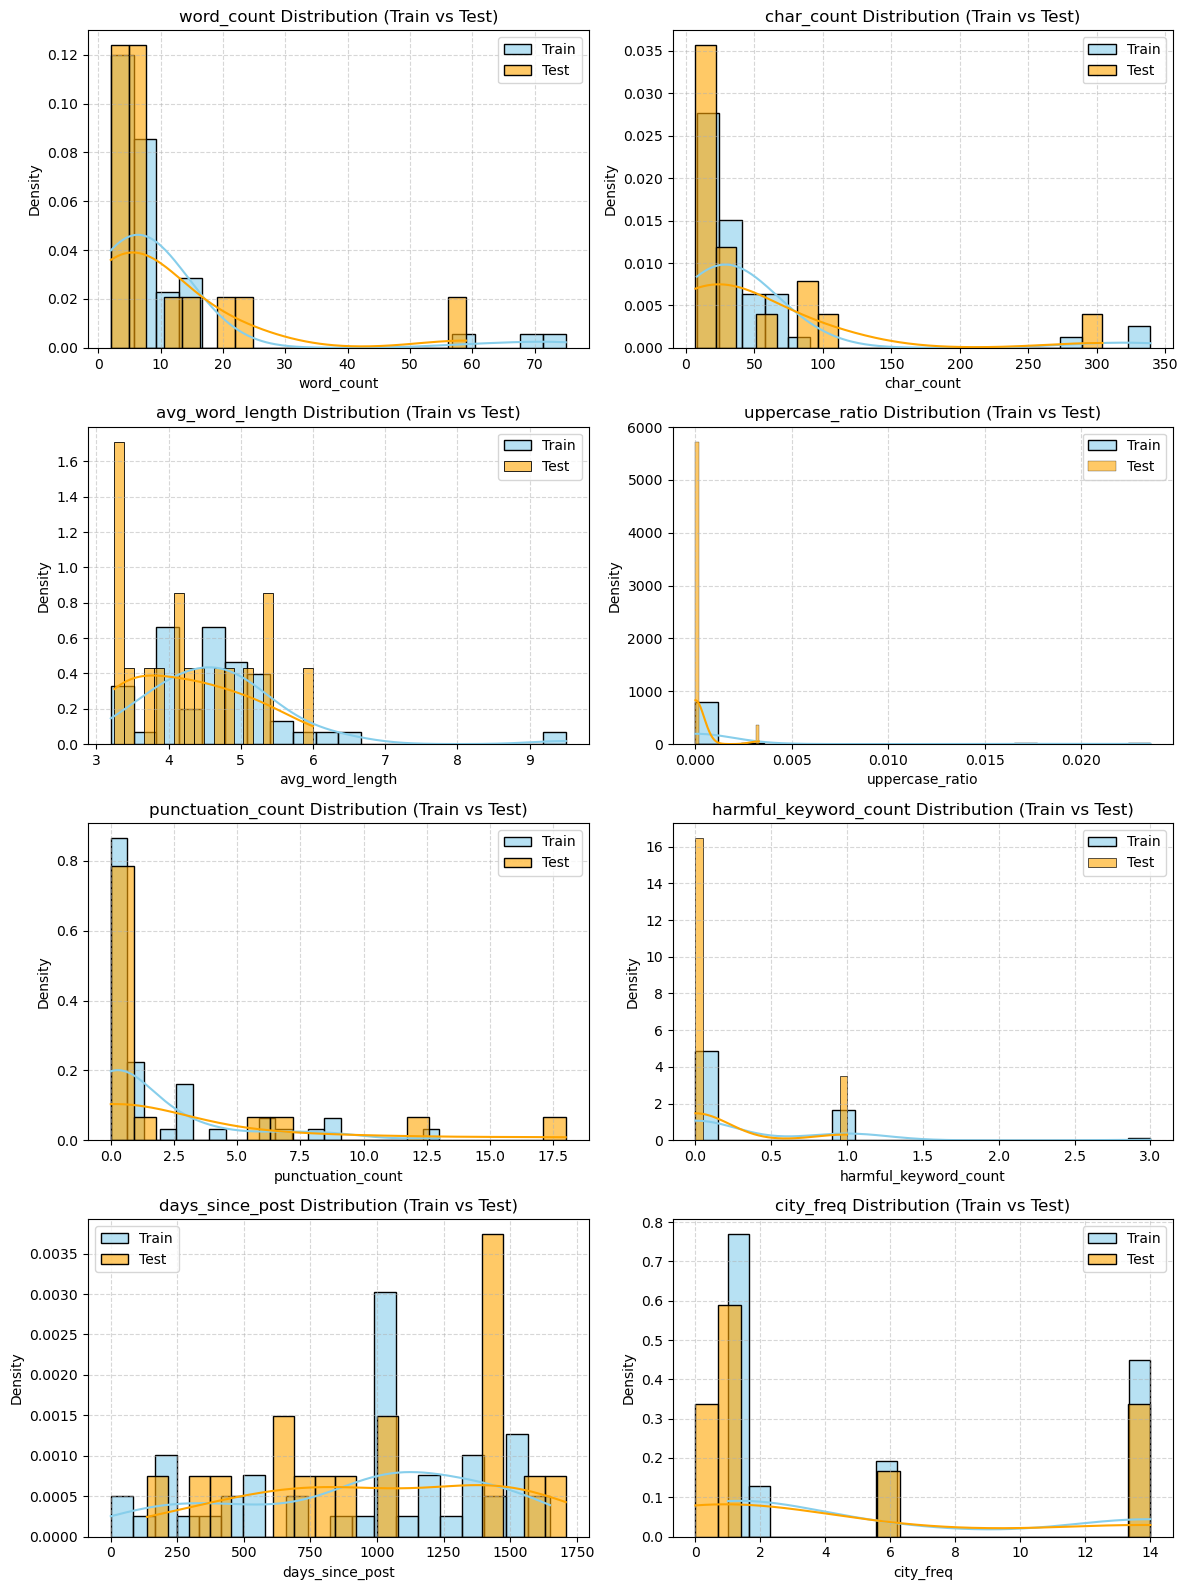

In [622]:
numeric_cols1 = [
    'word_count', 'char_count', 'avg_word_length', 'uppercase_ratio',
    'punctuation_count', 'harmful_keyword_count', 'days_since_post', 'city_freq'
]
plot_histograms_train_test(train_df, test_df, numeric_cols1)

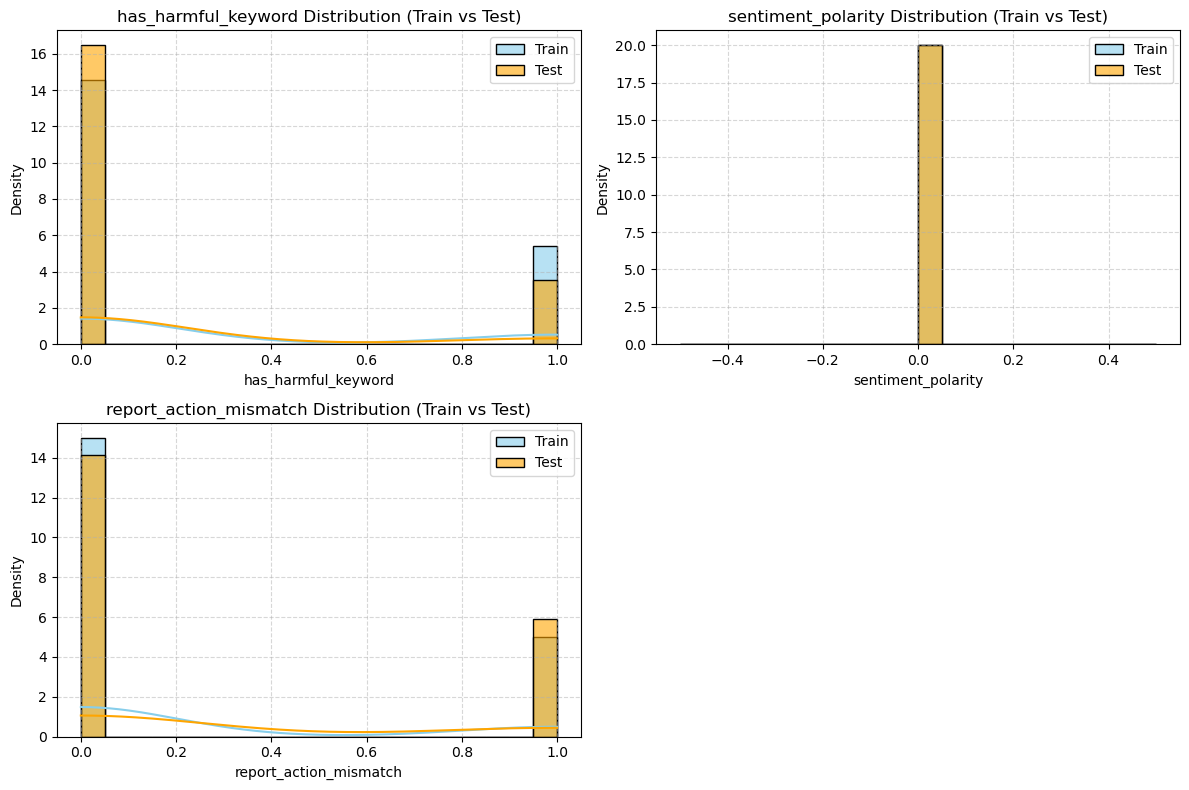

In [623]:
numeric_cols2 = [
    'has_harmful_keyword', 'sentiment_polarity', 'report_action_mismatch'
]
plot_histograms_train_test(train_df, test_df, numeric_cols2)

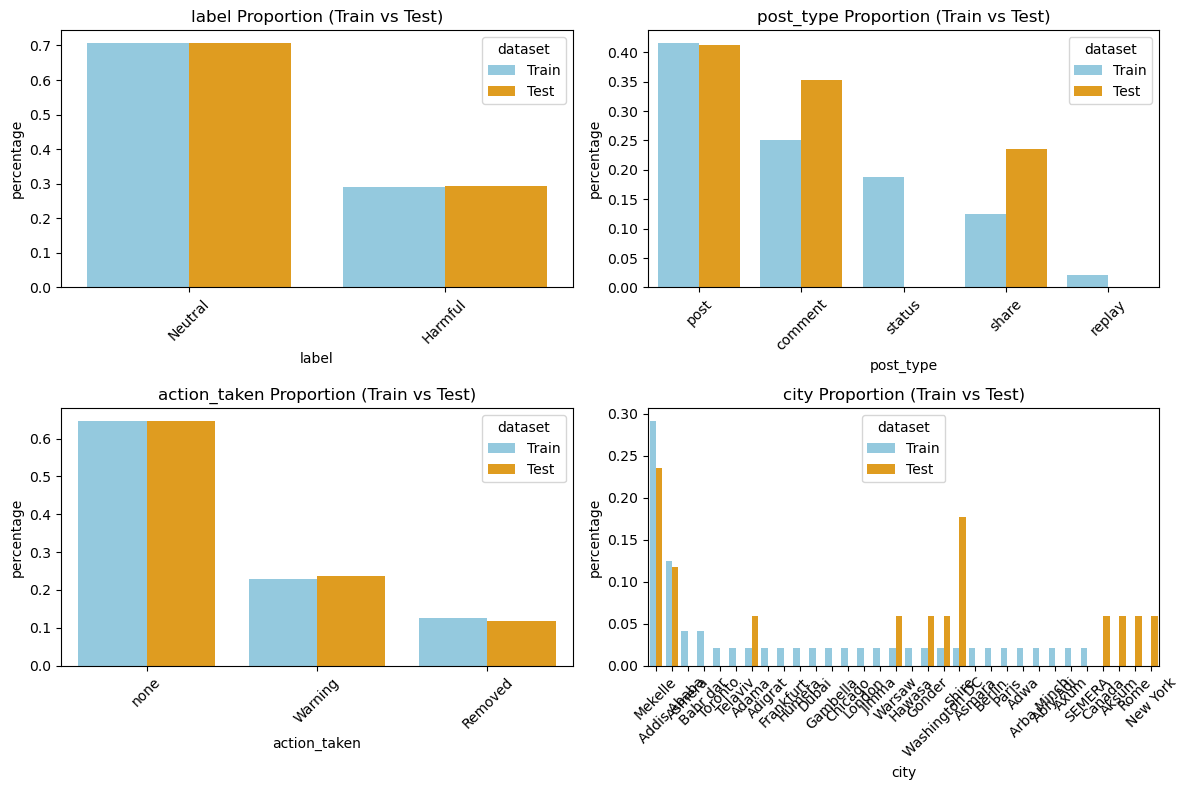

In [624]:
categorical_cols = ['label', 'post_type', 'action_taken', 'city']
plot_countplots_train_test(train_df, test_df, categorical_cols)

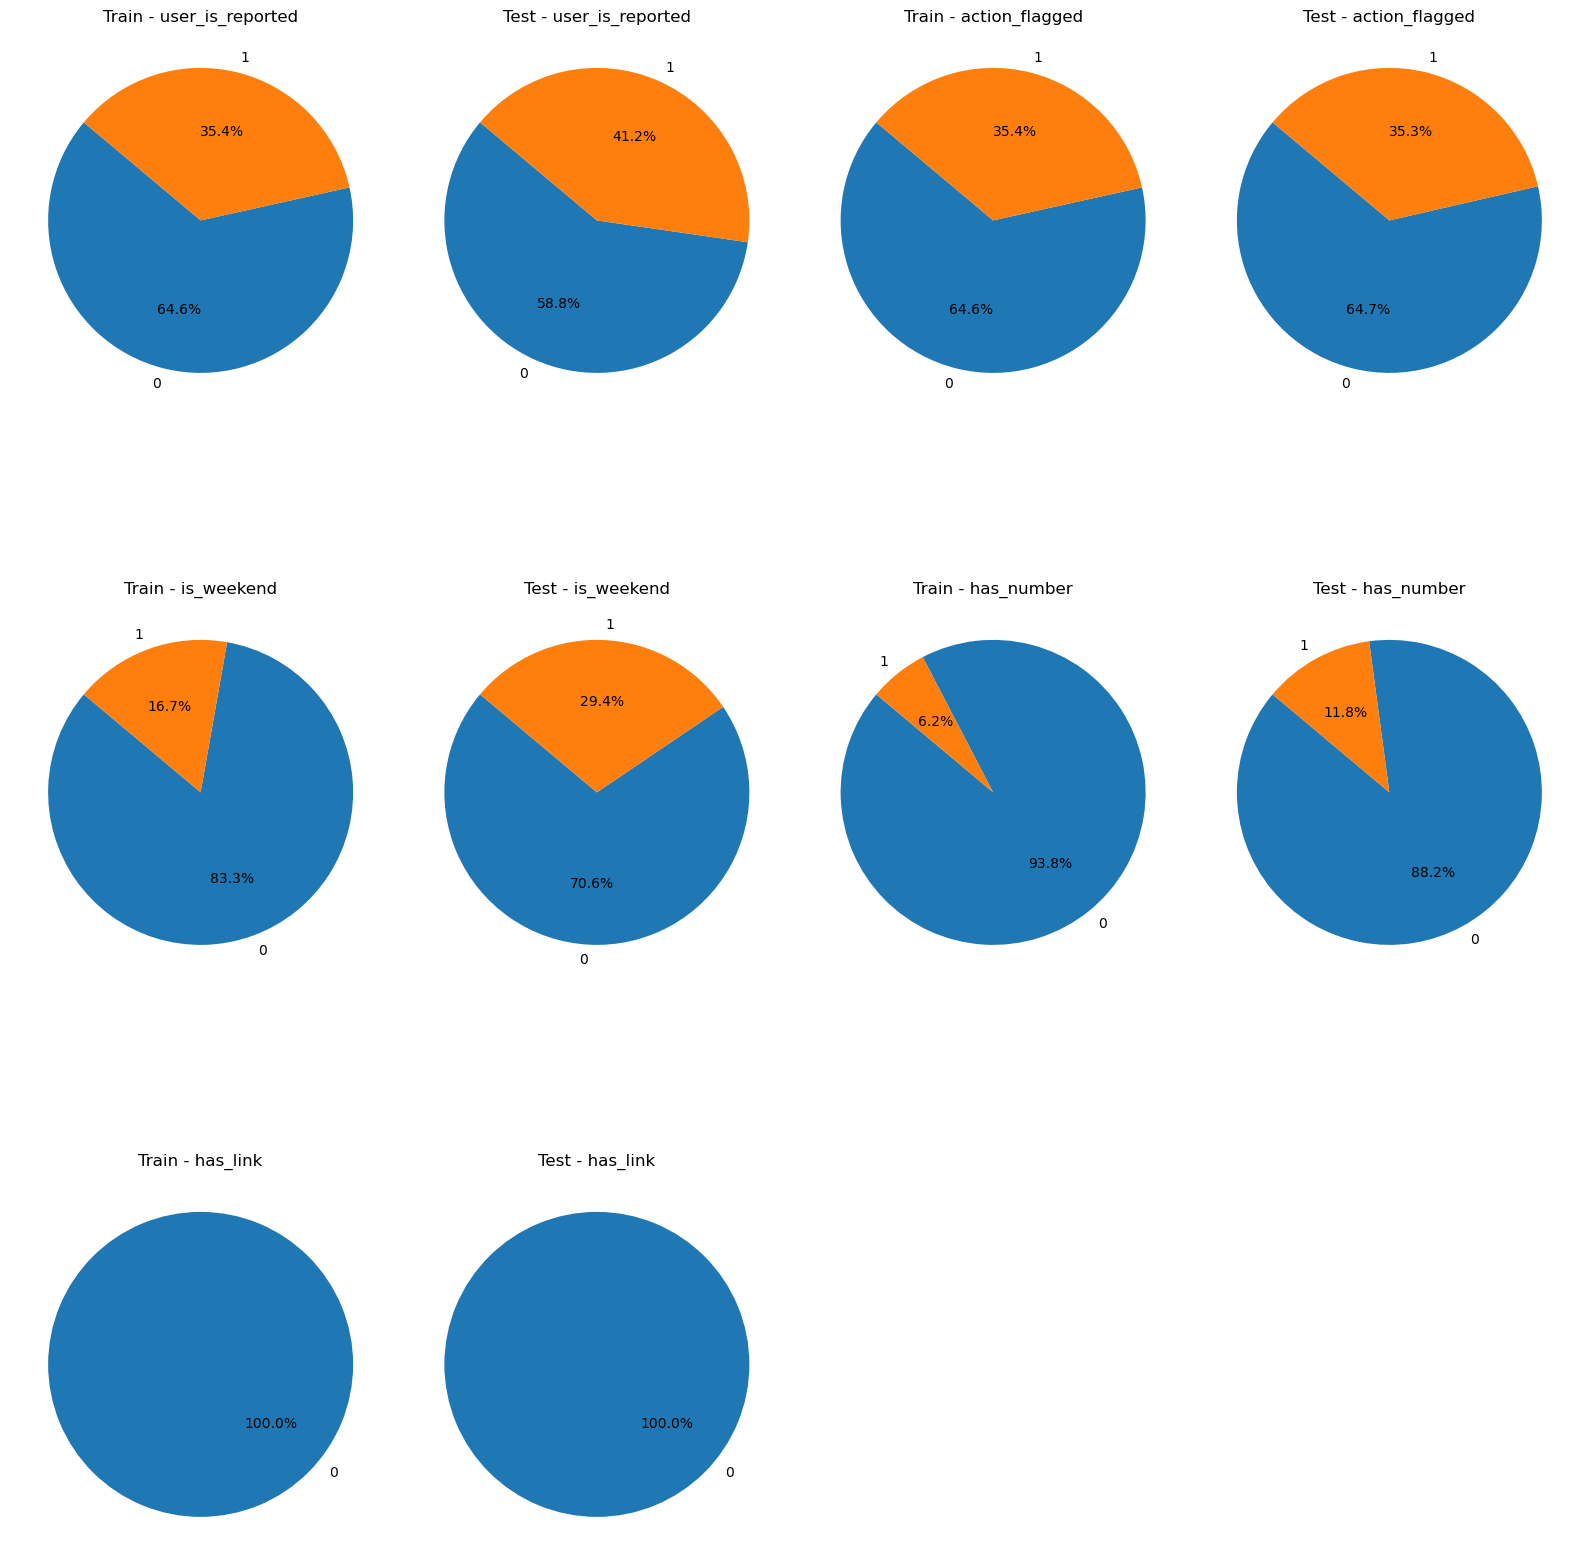

In [625]:
binary_cols = [
    'user_is_reported', 'action_flagged', 'is_weekend', 'has_number', 'has_link'
]
plot_pie_charts_train_test(train_df, test_df, binary_cols)

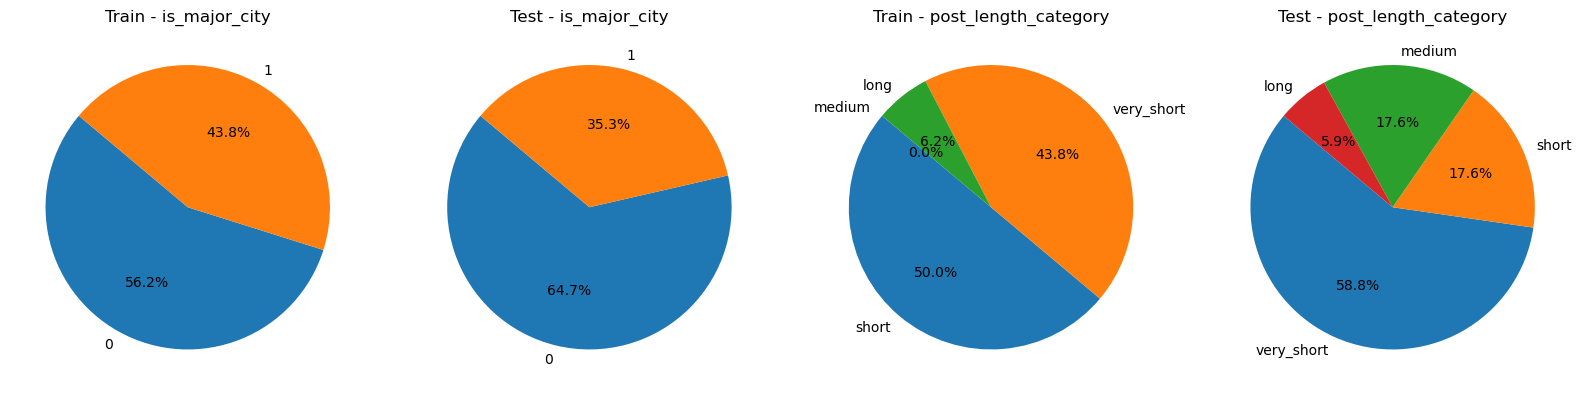

In [626]:
binary_cols = [  'is_major_city', 'post_length_category'
]
plot_pie_charts_train_test(train_df, test_df, binary_cols)

In [627]:
def plot_label_distribution(df, title='Label Distribution'):
    plt.figure(figsize=(6, 6))
    df['label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'orange'])
    plt.title(title)
    plt.ylabel('')
    plt.show()

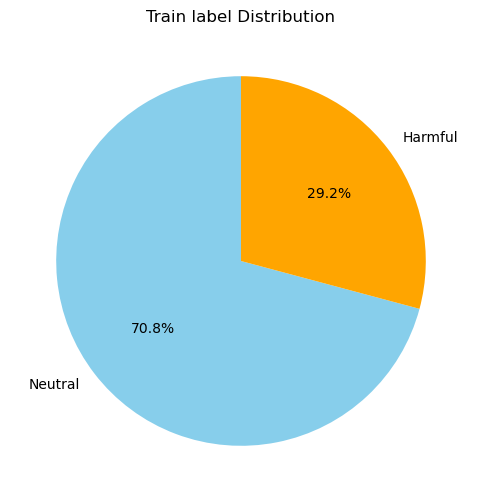

In [628]:
plot_label_distribution(train_df, title='Train label Distribution')

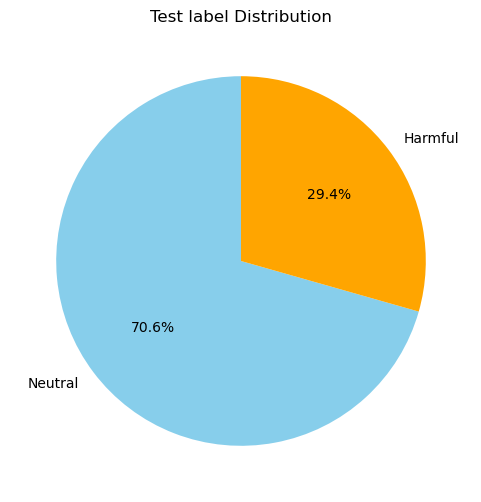

In [629]:
plot_label_distribution(test_df, title='Test label Distribution')

In [630]:
def plot_avg_wordcount_by_category(df, category_col):
    agg = df.groupby(category_col)['word_count'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(data=agg, x=category_col, y='word_count', palette='coolwarm')
    plt.title(f'Average Word Count by {category_col}')
    plt.xlabel(category_col)
    plt.ylabel('Average Word Count')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

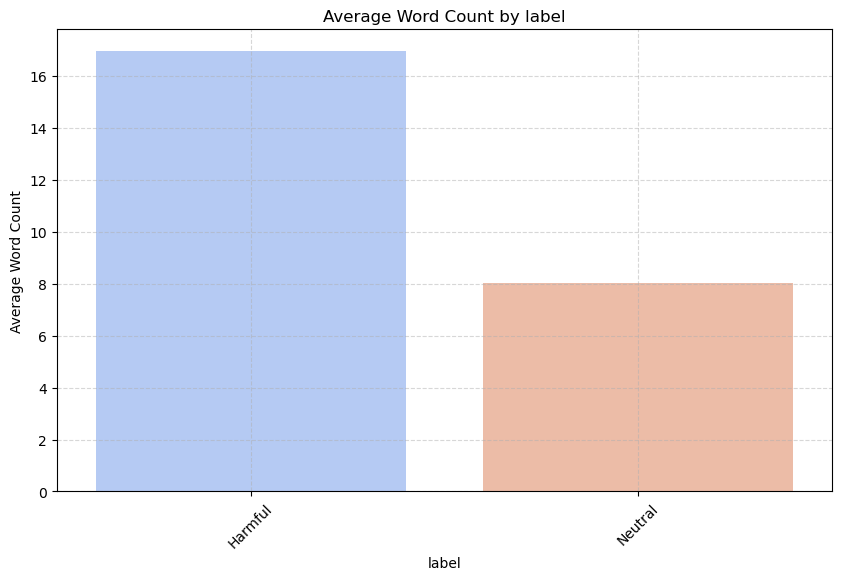

In [631]:
plot_avg_wordcount_by_category(train_df, 'label')

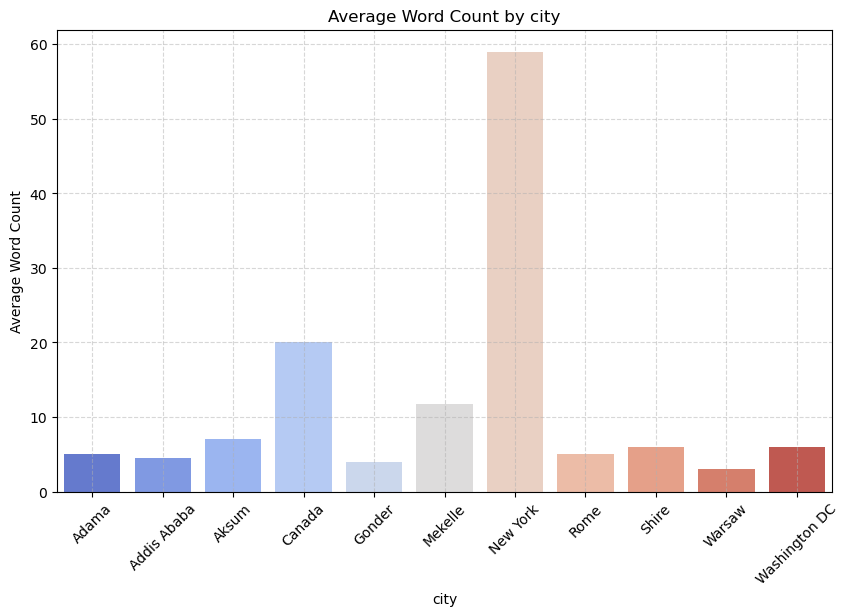

In [632]:
plot_avg_wordcount_by_category(test_df, 'city')

In [572]:
train_df['has_link'].value_counts()

has_link
0    48
Name: count, dtype: int64

In [573]:
test_df['has_link'].value_counts()

has_link
0    17
Name: count, dtype: int64

**Correlation Analysis**

In [635]:
def plot_correlation_heatmap(df, title='Correlation Matrix'):
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

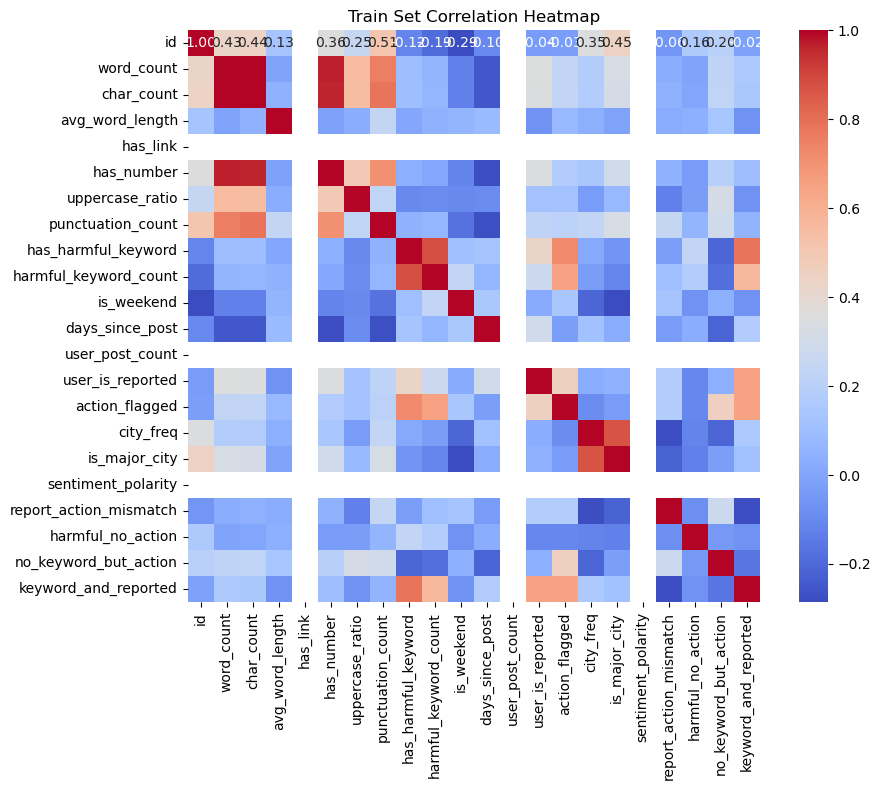

In [636]:
plot_correlation_heatmap(train_df, 'Train Set Correlation Heatmap')

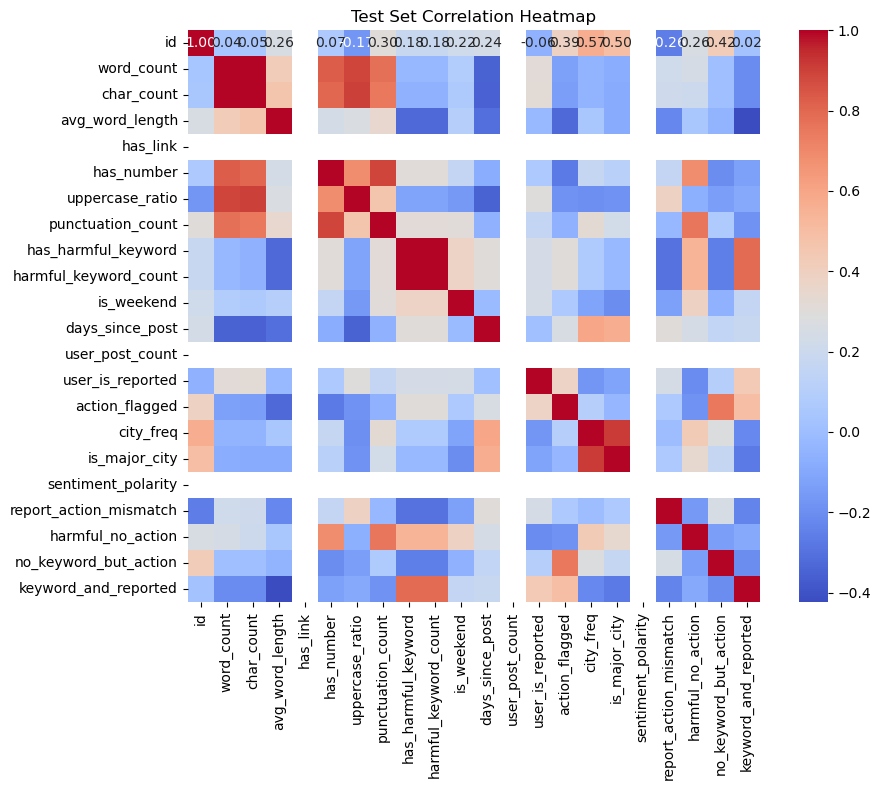

In [637]:
plot_correlation_heatmap(test_df, 'Test Set Correlation Heatmap')

From the above correlation heatmap we can see features like sentiment_polarity ,has_link, and user_post_count have no variance.
that means these variables have no predictive power for our ML model therefore we have to drop them.

**COLUMNS TO DROP**

In [638]:
train_df.shape

(48, 37)

In [639]:
test_df.shape

(17, 37)

In [640]:
cols_drop = ['id', 'user_reported_clean', 'language', 'name', 'content', 'date', 'city', 'has_link', 'user_post_count', 'sentiment_polarity']

In [641]:
train_df.drop(columns=cols_drop, inplace=True)
test_df.drop(columns=cols_drop, inplace=True)

In [642]:
train_df.shape

(48, 27)

**Encoding Process**

In [643]:
train_df.dtypes

post_type                   object
user_reported                 bool
action_taken                object
label                       object
word_count                   int64
char_count                   int64
avg_word_length            float64
has_number                   int64
uppercase_ratio            float64
punctuation_count            int64
has_harmful_keyword          int64
harmful_keyword_count        int64
post_hour                    int32
post_dayofweek               int32
is_weekend                   int64
post_month                   int32
post_year                    int32
days_since_post              int64
user_is_reported             int64
action_flagged               int64
city_freq                    int64
is_major_city                int64
report_action_mismatch       int64
post_length_category      category
harmful_no_action            int64
no_keyword_but_action        int64
keyword_and_reported         int64
dtype: object

In [644]:
for col in train_df.select_dtypes(include=["object", "category", "bool"]).columns:
    print(f"\n{col} ({train_df[col].nunique()} unique values):")
    print(train_df[col].unique())


post_type (5 unique values):
['comment' 'status' 'replay' 'post' 'share']

user_reported (2 unique values):
[False  True]

action_taken (3 unique values):
['Warning' 'none' 'Removed']

label (2 unique values):
['Neutral' 'Harmful']

post_length_category (3 unique values):
['short', 'very_short', 'long']
Categories (4, object): ['very_short' < 'short' < 'medium' < 'long']


In [645]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class CategoricalPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.post_type_categories = ['comment', 'status', 'replay', 'post', 'share']
        self.length_categories = ['very_short', 'short', 'medium', 'long']
        self.action_mapping = {'none': 0, 'Warning': 1, 'Removed': 2}
        self.feature_columns_ = None  # Will store column names for consistency
        
    def fit(self, X, y=None):
        # No fitting needed for manual mappings, but we'll store expected columns
        dummy_columns = (
            [f'type_{c}' for c in self.post_type_categories] +
            [f'length_{c}' for c in self.length_categories]
        )
        self.feature_columns_ = (
            X.drop(['post_type', 'post_length_category'], axis=1).columns.tolist() + 
            dummy_columns
        )
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # --- 1. Binary Encoding ---
        X['label'] = X['label'].map({'Neutral': 0, 'Harmful': 1}).astype(int)
        X['user_reported'] = X['user_reported'].astype(int)
        
        # --- 2. Ordinal Encoding ---
        X['action_taken'] = X['action_taken'].map(self.action_mapping).fillna(-1).astype(int)
        
        # --- 3. One-Hot Encoding ---
        # Post Type
        post_type_dummies = pd.get_dummies(
            X['post_type'], 
            prefix='type'
        ).reindex(columns=[f'type_{c}' for c in self.post_type_categories], fill_value=0)
        
        # Length Category (using pd.Categorical to enforce categories)
        length_series = pd.Categorical(
            X['post_length_category'], 
            categories=self.length_categories
        )
        length_dummies = pd.get_dummies(length_series, prefix='length')
        
        # Combine features
        X_transformed = pd.concat([
            X.drop(['post_type', 'post_length_category'], axis=1),
            post_type_dummies,
            length_dummies
        ], axis=1)
        
        # Ensure consistent columns (especially for test data)
        if self.feature_columns_ is not None:
            missing_cols = set(self.feature_columns_) - set(X_transformed.columns)
            for col in missing_cols:
                X_transformed[col] = 0
            X_transformed = X_transformed[self.feature_columns_]
        
        return X_transformed

# Usage
preprocessor = CategoricalPreprocessor()
train_df_processed = preprocessor.fit_transform(train_df)
test_df_processed = preprocessor.transform(test_df)

In [646]:
train_df.head()

,post_type,user_reported,action_taken,label,word_count,char_count,avg_word_length,has_number,uppercase_ratio,punctuation_count,...,days_since_post,user_is_reported,action_flagged,city_freq,is_major_city,report_action_mismatch,post_length_category,harmful_no_action,no_keyword_but_action,keyword_and_reported
0,comment,False,Warning,Neutral,14,73,5.214286,0,0.000000,9,...,0,0,1,1,0,1,short,0,1,0
1,status,False,none,Neutral,3,16,5.333333,0,0.000000,0,...,1036,0,0,14,1,0,very_short,0,0,0
2,replay,False,none,Neutral,4,14,3.500000,0,0.000000,0,...,1036,0,0,14,1,0,very_short,0,0,0
3,post,True,Warning,Harmful,75,339,4.520000,1,0.023599,8,...,544,1,1,6,1,0,long,0,1,0
4,status,False,none,Neutral,10,49,4.900000,0,0.000000,3,...,1036,0,0,1,0,0,short,1,0,0


In [648]:
train_df_processed.head()

,user_reported,action_taken,label,word_count,char_count,avg_word_length,has_number,uppercase_ratio,punctuation_count,has_harmful_keyword,...,keyword_and_reported,type_comment,type_status,type_replay,type_post,type_share,length_very_short,length_short,length_medium,length_long
0,0,1,0,14,73,5.214286,0,0.000000,9,0,...,0,True,False,False,False,False,False,True,False,False
1,0,0,0,3,16,5.333333,0,0.000000,0,0,...,0,False,True,False,False,False,True,False,False,False
2,0,0,0,4,14,3.500000,0,0.000000,0,0,...,0,False,False,True,False,False,True,False,False,False
3,1,1,1,75,339,4.520000,1,0.023599,8,0,...,0,False,False,False,True,False,False,False,False,True
4,0,0,0,10,49,4.900000,0,0.000000,3,1,...,0,False,True,False,False,False,False,True,False,False


In [649]:
test_df_processed.head()

,user_reported,action_taken,label,word_count,char_count,avg_word_length,has_number,uppercase_ratio,punctuation_count,has_harmful_keyword,...,keyword_and_reported,type_comment,type_status,type_replay,type_post,type_share,length_very_short,length_short,length_medium,length_long
0,1,1,1,16,85,5.312500,0,0.0,7,0,...,0,False,0,0,True,False,False,False,True,False
1,1,1,1,3,10,3.333333,0,0.0,0,1,...,1,False,0,0,False,True,True,False,False,False
2,0,0,0,4,24,6.000000,0,0.0,0,0,...,0,True,0,0,False,False,True,False,False,False
3,1,0,0,5,19,3.800000,0,0.0,0,0,...,0,True,0,0,False,False,True,False,False,False
4,0,1,0,2,7,3.500000,0,0.0,0,0,...,0,True,0,0,False,False,True,False,False,False


In [650]:
test_df_processed.dtypes

user_reported               int64
action_taken                int64
label                       int64
word_count                  int64
char_count                  int64
avg_word_length           float64
has_number                  int64
uppercase_ratio           float64
punctuation_count           int64
has_harmful_keyword         int64
harmful_keyword_count       int64
post_hour                   int32
post_dayofweek              int32
is_weekend                  int64
post_month                  int32
post_year                   int32
days_since_post             int64
user_is_reported            int64
action_flagged              int64
city_freq                 float64
is_major_city               int64
report_action_mismatch      int64
harmful_no_action           int64
no_keyword_but_action       int64
keyword_and_reported        int64
type_comment                 bool
type_status                 int64
type_replay                 int64
type_post                    bool
type_share    

In [651]:
tig_test=test_df_processed

In [652]:
tig_train=train_df_processed

In [702]:
import pandas as pd
import os

# Define the directory path
directory = "/Users/a1234/Documents/myProject/tigrinya_ml_api/data"

# Create directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save both DataFrames
tig_train.to_csv(os.path.join(directory, "tig_train.csv"), index=False)
tig_test.to_csv(os.path.join(directory, "tig_test.csv"), index=False)

In [703]:
tig_df.to_csv(os.path.join(directory, "tig_meta_data.csv"), index=False)

In [654]:
def feature_label_correlation(df, target_col='label'):
    """Calculate correlation between numeric features and target column."""
    # Convert target to numeric if needed
    if not np.issubdtype(df[target_col].dtype, np.number):
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    
    # Select numeric columns (including converted target)
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    if target_col not in numeric_cols:
        raise ValueError(f"Target column '{target_col}' cannot be converted to numeric or is missing.")
    
    # Calculate correlations
    corr_df = df[numeric_cols].corr()[[target_col]].drop(target_col)
    corr_df.columns = ['Correlation_with_Label']
    
    return corr_df.sort_values('Correlation_with_Label', key=abs, ascending=False)

In [656]:
feature_label_correlation(tig_train, target_col='label')

,Correlation_with_Label
action_flagged,0.866525
action_taken,0.861945
has_harmful_keyword,0.846617
harmful_keyword_count,0.756759
keyword_and_reported,0.748625
user_is_reported,0.579014
user_reported,0.579014
word_count,0.261357
char_count,0.259243
has_number,0.213021


In [657]:
feature_label_correlation(tig_test, target_col='label')

,Correlation_with_Label
action_flagged,0.874007
action_taken,0.861961
keyword_and_reported,0.565685
no_keyword_but_action,0.554989
user_reported,0.509201
user_is_reported,0.509201
has_harmful_keyword,0.378489
harmful_keyword_count,0.378489
has_number,-0.235702
avg_word_length,-0.220098


In [667]:
tig_train.columns

Index(['user_reported', 'action_taken', 'label', 'word_count', 'char_count',
       'avg_word_length', 'has_number', 'uppercase_ratio', 'punctuation_count',
       'has_harmful_keyword', 'harmful_keyword_count', 'post_hour',
       'post_dayofweek', 'is_weekend', 'post_month', 'post_year',
       'days_since_post', 'user_is_reported', 'action_flagged', 'city_freq',
       'is_major_city', 'report_action_mismatch', 'harmful_no_action',
       'no_keyword_but_action', 'keyword_and_reported', 'type_comment',
       'type_status', 'type_replay', 'type_post', 'type_share',
       'length_very_short', 'length_short', 'length_medium', 'length_long'],
      dtype='object')

In [659]:
import os
import pandas as pd

# Define the base directory from the original dataset path
base_path = "/Users/a1234/meta_tigrinya_dataset_cleaned.csv"
directory = os.path.dirname(base_path)

# Save train and test datasets
tig_train.to_csv(os.path.join(directory, "tig_train.csv"), index=False)
tig_test.to_csv(os.path.join(directory, "tig_test.csv"), index=False)

print(f"Train dataset saved to: {os.path.join(directory, 'tig_train.csv')}")
print(f"Test dataset saved to: {os.path.join(directory, 'tig_test.csv')}")

Train dataset saved to: /Users/a1234/tig_train.csv
Test dataset saved to: /Users/a1234/tig_test.csv


In [660]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# Check columns (should match your processed features)
print("Train columns:", tig_train.columns.tolist())
print("Test columns:", tig_test.columns.tolist())

# Ensure target exists
assert 'label' in tig_train.columns, "Missing 'label' in train"
assert 'label' in tig_test.columns, "Missing 'label' in test"

Train columns: ['user_reported', 'action_taken', 'label', 'word_count', 'char_count', 'avg_word_length', 'has_number', 'uppercase_ratio', 'punctuation_count', 'has_harmful_keyword', 'harmful_keyword_count', 'post_hour', 'post_dayofweek', 'is_weekend', 'post_month', 'post_year', 'days_since_post', 'user_is_reported', 'action_flagged', 'city_freq', 'is_major_city', 'report_action_mismatch', 'harmful_no_action', 'no_keyword_but_action', 'keyword_and_reported', 'type_comment', 'type_status', 'type_replay', 'type_post', 'type_share', 'length_very_short', 'length_short', 'length_medium', 'length_long']
Test columns: ['user_reported', 'action_taken', 'label', 'word_count', 'char_count', 'avg_word_length', 'has_number', 'uppercase_ratio', 'punctuation_count', 'has_harmful_keyword', 'harmful_keyword_count', 'post_hour', 'post_dayofweek', 'is_weekend', 'post_month', 'post_year', 'days_since_post', 'user_is_reported', 'action_flagged', 'city_freq', 'is_major_city', 'report_action_mismatch', 'harm

In [661]:
# Separate features (X) and target (y)
X_train = tig_train.drop('label', axis=1)
y_train = tig_train['label']
X_test = tig_test.drop('label', axis=1)
y_test = tig_test['label']

# Verify shapes
print(f"Train shapes - X: {X_train.shape}, y: {y_train.shape}")
print(f"Test shapes - X: {X_test.shape}, y: {y_test.shape}")

Train shapes - X: (48, 33), y: (48,)
Test shapes - X: (17, 33), y: (17,)


In [690]:
X_train.columns

Index(['user_reported', 'action_taken', 'word_count', 'char_count',
       'avg_word_length', 'has_number', 'uppercase_ratio', 'punctuation_count',
       'has_harmful_keyword', 'harmful_keyword_count', 'post_hour',
       'post_dayofweek', 'is_weekend', 'post_month', 'post_year',
       'days_since_post', 'user_is_reported', 'action_flagged', 'city_freq',
       'is_major_city', 'report_action_mismatch', 'harmful_no_action',
       'no_keyword_but_action', 'keyword_and_reported', 'type_comment',
       'type_status', 'type_replay', 'type_post', 'type_share',
       'length_very_short', 'length_short', 'length_medium', 'length_long'],
      dtype='object')

In [662]:
#  Calculate class weights
neutral_count = len(y_train[y_train == 0])
harmful_count = len(y_train[y_train == 1])
scale_pos_weight = neutral_count / harmful_count  # Critical for imbalance
print(f"Class balance - Neutral: {neutral_count}, Harmful: {harmful_count}")
print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")

Class balance - Neutral: 34, Harmful: 14
Using scale_pos_weight: 2.43


In [663]:
# XGBoost Model with Tigrinya-specific tuning
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric=['aucpr', 'logloss'],  # Focus on harm detection precision
    n_estimators=500,                  # Increased for small dataset
    max_depth=4,                       # Reduced to prevent overfitting
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    gamma=0.3,                         # Regularization
    scale_pos_weight=scale_pos_weight, # Critical for your 2.43:1 imbalance
    early_stopping_rounds=20,
    random_state=42,
    tree_method='hist'                 # Efficient for your feature types
)

#Train with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

[0]	validation_0-aucpr:0.80354	validation_0-logloss:0.65863
[10]	validation_0-aucpr:0.98109	validation_0-logloss:0.44538
[20]	validation_0-aucpr:0.98109	validation_0-logloss:0.33483
[30]	validation_0-aucpr:0.96354	validation_0-logloss:0.26204
[40]	validation_0-aucpr:0.96354	validation_0-logloss:0.22145
[50]	validation_0-aucpr:0.96354	validation_0-logloss:0.19586
[60]	validation_0-aucpr:0.96354	validation_0-logloss:0.18324
[70]	validation_0-aucpr:0.96354	validation_0-logloss:0.17208
[80]	validation_0-aucpr:0.96354	validation_0-logloss:0.15669
[90]	validation_0-aucpr:0.96354	validation_0-logloss:0.15660
[100]	validation_0-aucpr:0.96354	validation_0-logloss:0.15509
[110]	validation_0-aucpr:0.96354	validation_0-logloss:0.16038
[116]	validation_0-aucpr:0.96354	validation_0-logloss:0.16070


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=['aucpr', 'logloss'],
              feature_types=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [664]:
#  Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Tigrinya Harmful Post Detection ===")
print(f"Train Samples: {len(X_train)} (Harmful: {y_train.sum()})")
print(f"Test Samples: {len(X_test)} (Harmful: {y_test.sum()})\n")

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Harmful']))


=== Tigrinya Harmful Post Detection ===
Train Samples: 48 (Harmful: 14)
Test Samples: 17 (Harmful: 5)

              precision    recall  f1-score   support

     Neutral       0.92      1.00      0.96        12
     Harmful       1.00      0.80      0.89         5

    accuracy                           0.94        17
   macro avg       0.96      0.90      0.92        17
weighted avg       0.95      0.94      0.94        17



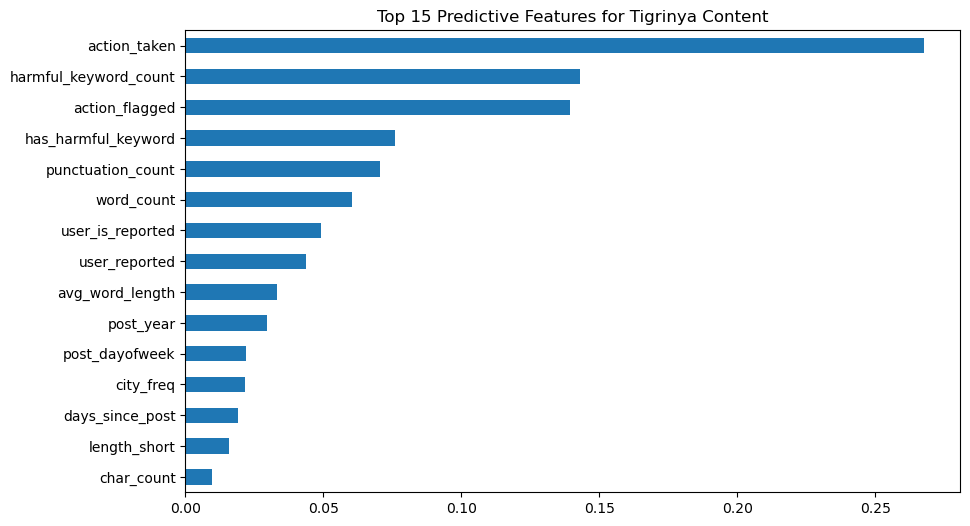

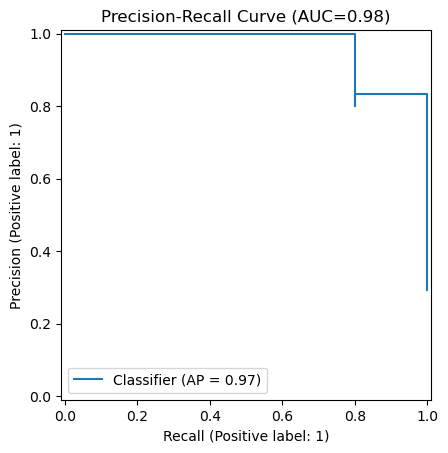

In [665]:
# Feature Importance (Tigrinya-specific)
plt.figure(figsize=(10, 6))
pd.Series(model.feature_importances_, index=X_train.columns
       ).nlargest(15).sort_values().plot.barh()
plt.title("Top 15 Predictive Features for Tigrinya Content")
plt.show()

# 7. Precision-Recall Curve (Critical for harm detection)
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f'Precision-Recall Curve (AUC={roc_auc_score(y_test, y_proba):.2f})')
plt.show()

//DONE//

**BELOW IS FOR APP DEVELOPMENT**

Step 1: Feature Extraction Function

In [671]:
import re
import numpy as np
import pandas as pd

# Define your harmful keywords (Tigrinya-specific)
HARMFUL_KEYWORDS = [ "ደማት", "ነገራትኩም ግጉይን ሰይጣናውን ዩ", "ይተርፍ", "በሎ", "ምስንቱ ኣነ", "ድሮም አስኩም ዶ ዘይትረብሑ",
    "ምጉሓፎም", "ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም", "ቡዳ", "ጠቢብ", "በላዕቲ ሰብ አዮም",
    "ትኳን ዝኮነ ህዝቢ", "ደማዊ ጦርነት", "ዲቃላ", "ይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ",
    "ክርችሽኑ አዩ ዘለዎም", "ዘይሰብ", "ንሰብ ዘይመስል", "ቀታሊ አዩ",
    "ንህዝብና ቀተልቱ መራሕትና አዮም", "ናብ ውግእ", "ዘርኣዊ ፅንተት", "ኣምባገነንነት",
    "ዘቅትል ዘረሽንን", "ወረርቲ ሓይልታት ዝሞቱ", "ህበይ", "ወዓግ", "ተመን", "ጨምላቕ",
    "ግብረ እከይ", "ኢዚ ሰብ ዘይኮነ", "ነዚኦም ከመይ ኢልና ንሓዝነሎም", "ሰይጣን", "ቐታ", "ጦርነት",
    "ኩናት", "ውግእ", "ወዲ ሻርሙጣ", "ወዲ ዓጣሪት",
    "ፅናሕ ከርእየካ እየ ግዜኻ ተፀበ", "ሃይማኖትኩም ትክክለኛ ኣይኮነን", "አድጊ","ደማት", "ነገራትኩም ግጉይን ሰይጣናውን ዩ", "ይተርፍ", "በሎ", "ምስንቱ ኣነ", 
    "ድሮም አስኩም ዶ ዘይትረብሑ", "ምጉሓፎም", "ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም", 
    "ቡዳ", "ጠቢብ", "በላዕቲ ሰብ አዮም", "ትኳን ዝኮነ ህዝቢ", "ደማዊ ጦርነት", 
    "ዲቃላ", "ይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ", "ክርችሽኑ አዩ ዘለዎም", "ዘይሰብ", 
    "ንሰብ ዘይመስል", "ቀታሊ አዩ", "ንህዝብና ቀተልቱ መራሕትና አዮም", "ናብ ውግእ", 
    "ዘርኣዊ ፅንተት", "ኣምባገነንነት", "ዘቅትል ዘረሽንን", "ወረርቲ ሓይልታት ዝሞቱ", 
    "ህበይ", "ወዓግ", "ተመን", "ጨምላቕ", "ግብረ እከይ", "ኢዚ ሰብ ዘይኮነ", 
    "ነዚኦም ከመይ ኢልና ንሓዝነሎም", "ሰይጣን", "ቐታ", "ጦርነት", "ኩናት", "ውግእ", 
    "ወዲ ሻርሙጣ", "ወዲ ዓጣሪት", "ፅናሕ ከርእየካ እየ ግዜኻ ተፀበ", 
    "ሃይማኖትኩም ትክክለኛ ኣይኮነን", "አድጊ", "ዓሻ", "ጨዋም", "ኣራጊ", "ዘይብሉ", 
    "ደንጉዛ", "ጭራሽ", "ሓሰኻ", "ግድፍ", "ኣዝሒልካ", "በደል", "ውርጪ", "ኣይነብርካን", 
    "ከተማ ዘይብሉ", "ደኣ እምበር", "ኣይትኾንካ", "ጨፍጫፋ", "ኣይትግበር", 
    "ጨራሽ ወዲ", "ዘርኢ �ንጣ", "ኣይትጸግብ", "ባእዳዊ", "ኣረጋጋጽ", "ዘርኢ ኣረማዊ", 
    "ጨራሽ ኣይነበረትን", "ኣይትሓስብ", "ዓሻ ዝበሃል እዩ", "ኣይትንቀሳቀስ", 
    "ወዲ ሽምኩር", "እዚ ሰብ ዘይኮነ", "ኣይትግለጽ", "ኣይትነግር", "ጽልኢ", 
    "ኣይኮነን ሰብ", "ዘርኢ ገዛእቲ", "ኣረጋጋጽ ሕማም", "ኣይትሰማማዕ", 
    "ዘይትፈልጥ", "ኣይትበሃል", "ንህዝብና ቀተልቱ", "ኣንስተይቲ ኣይትኾንኪ", 
    "ንህዝብና ይበልዑ", "መራሕትና ኣረጋጋጽ እዮም", "እምነት ዘይብሎም", 
    "ጋውጋው", "ክርሽታን አዩ ዘለዎም"
]

def extract_features(text):
    """Extract all features required by your model from raw text"""
    features = {}
    
    # 1. Text statistics
    words = text.split()
    features['word_count'] = len(words)
    features['char_count'] = len(text)
    features['avg_word_length'] = features['char_count'] / features['word_count'] if features['word_count'] > 0 else 0
    features['has_number'] = int(any(char.isdigit() for char in text))
    
    # Calculate uppercase ratio
    uppercase_chars = sum(1 for char in text if char.isupper())
    features['uppercase_ratio'] = uppercase_chars / features['char_count'] if features['char_count'] > 0 else 0
    
    # Punctuation count
    features['punctuation_count'] = len(re.findall(r'[^\w\s]', text))
    
    # 2. Harmful keyword detection
    matched_keywords = [kw for kw in HARMFUL_KEYWORDS if kw in text]
    features['has_harmful_keyword'] = int(len(matched_keywords) > 0)
    features['harmful_keyword_count'] = len(matched_keywords)
    
    # 3. Contextual features (set defaults for demo)
    features['user_reported'] = 0  # Assume not reported by user
    features['action_taken'] = 0    # Default: no action
    features['user_is_reported'] = 0
    features['action_flagged'] = 0
    features['report_action_mismatch'] = 0
    features['harmful_no_action'] = 0
    features['no_keyword_but_action'] = 0
    features['keyword_and_reported'] = 0
    
    # 4. Temporal features (using current time)
    from datetime import datetime
    now = datetime.now()
    features['post_hour'] = now.hour
    features['post_dayofweek'] = now.weekday()  # Monday=0, Sunday=6
    features['is_weekend'] = int(features['post_dayofweek'] >= 5)  # 1 if Sat/Sun
    features['post_month'] = now.month
    features['post_year'] = now.year
    features['days_since_post'] = 0  # Assuming posted now
    
    # 5. Location features
    features['city_freq'] = 0.5  # Default frequency
    features['is_major_city'] = 0  # Assume not major city
    
    # 6. Post type (set default to 'post')
    features['type_comment'] = 0
    features['type_status'] = 0
    features['type_replay'] = 0
    features['type_post'] = 1  # Default to post
    features['type_share'] = 0
    
    # 7. Length categories (based on word count)
    word_count = features['word_count']
    features['length_very_short'] = int(word_count <= 5)
    features['length_short'] = int(5 < word_count <= 15)
    features['length_medium'] = int(15 < word_count <= 30)
    features['length_long'] = int(word_count > 30)
    
    return features, matched_keywords

Step 2: Create UI Widgets

In [672]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# Create UI components
post_input = widgets.Textarea(
    value='',
    placeholder='Enter Tigrinya post here...',
    description='Post:',
    layout=widgets.Layout(width='80%', height='100px')
)

analyze_btn = widgets.Button(description="Analyze Post")
output = widgets.Output()

examples = widgets.HTML(
    value="<b>Examples:</b><br>" + 
          "gp+h-4.h-hA=::<br>" +
          "h+h-1.h-3.h-2::<br>" +
          "gp+h+h-1 HHA.h-2::"
)

# Add some styling
title = widgets.HTML("<h2 style='color:#1a5276'>Tigrinya Harmful Post Detector</h2>")

Step 3: Prediction and Display Function

In [673]:
#  model metrics from evaluation
MODEL_ACCURACY = 0.94  # From classification report
CONFUSION_MATRIX = np.array([[12, 0], [1, 4]])  # From your metrics: [TN, FP], [FN, TP]

def analyze_post(b):
    with output:
        clear_output()
        text = post_input.value.strip()
        
        if not text:
            print("Please enter a Tigrinya post")
            return
            
        # Extract features and keywords
        features, matched_keywords = extract_features(text)
        features_df = pd.DataFrame([features])
        
        # Ensure column order matches training
        features_df = features_df[X_train.columns]
        
        # Predict
        prediction = model.predict(features_df)[0]
        probability = model.predict_proba(features_df)[0][1]
        
        # Display results
        display(widgets.HTML(f"<h3 style='color:#1a5276'>Analysis Results</h3>"))
        
        # Keyword section
        display(widgets.HTML(f"<b>Matched Keywords:</b> {', '.join(matched_keywords) if matched_keywords else 'None'}"))
        display(widgets.HTML(f"<b>Keyword Count:</b> {len(matched_keywords)}"))
        
        # Prediction section
        prediction_text = "Harmful 🚨" if prediction == 1 else "Neutral ✅"
        prediction_color = "#c0392b" if prediction == 1 else "#27ae60"
        display(widgets.HTML(
            f"<b>Prediction:</b> <span style='color:{prediction_color}; font-weight:bold'>{prediction_text}</span> "
            f"(Confidence: {probability*100:.1f}%)"
        ))
        
        # Model performance
        display(widgets.HTML(f"<b>Model Accuracy:</b> {MODEL_ACCURACY*100:.2f}%"))
        
        # Confusion matrix visualization
        display(widgets.HTML("<b>Confusion Matrix:</b>"))
        plt.figure(figsize=(6, 4))
        sns.heatmap(CONFUSION_MATRIX, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted Neutral', 'Predicted Harmful'],
                    yticklabels=['Actual Neutral', 'Actual Harmful'])
        plt.title('Model Performance on Test Data')
        plt.show()
        
        # Additional insights
        display(widgets.HTML("<b>Detection Insights:</b>"))
        if matched_keywords:
            display(widgets.HTML(f"- Found {len(matched_keywords)} harmful keyword(s)"))
        if prediction == 1:
            display(widgets.HTML("- High probability of harmful content"))
            if probability > 0.9:
                display(widgets.HTML("- ⚠️ Strong confidence in harmful classification"))
        else:
            display(widgets.HTML("- Content appears neutral"))
            if len(matched_keywords) > 0:
                display(widgets.HTML("- Note: Keywords found but context appears neutral"))

# Connect button to handler
analyze_btn.on_click(analyze_post)

Step 4: Display the Interface

In [674]:
# Display the full UI
display(title)
display(widgets.HTML("<p>Detects harmful content in Tigrinya posts using AI and keyword analysis</p>"))
display(post_input)
display(analyze_btn)
display(examples)
display(output)

HTML(value="<h2 style='color:#1a5276'>Tigrinya Harmful Post Detector</h2>")

HTML(value='<p>Detects harmful content in Tigrinya posts using AI and keyword analysis</p>')

Textarea(value='', description='Post:', layout=Layout(height='100px', width='80%'), placeholder='Enter Tigriny…

Button(description='Analyze Post', style=ButtonStyle())

HTML(value='<b>Examples:</b><br>gp+h-4.h-hA=::<br>h+h-1.h-3.h-2::<br>gp+h+h-1 HHA.h-2::')

Output()

TIGRINYA HARMFUL CONTENT DETECTOR
Examples:
gp+h-4.h-hA=::
h+h-1.h-3.h-2::
gp+h+h-1 HHA.h-2::




Enter Tigrinya post:
 ሰይጣን



Analyzing post...


**📍 Tigrinya Harmful Post Detection**

**Input Text:** `ሰይጣን...`

**Matched Keywords:** ሰይጣን, ሰይጣን

**Keyword Count:** 2

**Prediction:** <span style='color:red'>Harmful 🚨</span> (Confidence: 80.0%)

**Model Accuracy:** 94.00%

**Confusion Matrix:**

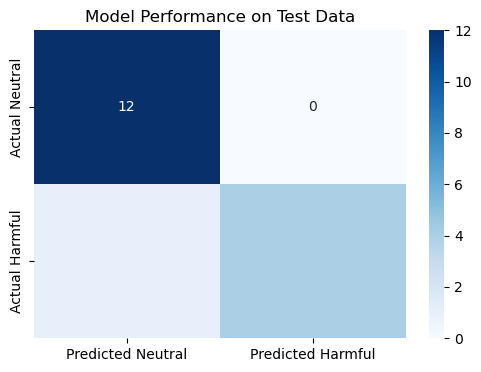

**Detection Insights:**

- Found 2 harmful keyword(s)

- High probability of harmful content

---

In [683]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Define your harmful keywords (Tigrinya-specific)
# HARMFUL_KEYWORDS = ["UIDE", "D4T", "+DT", "C0L", "h+h-1", "h-3", "HHA"]
HARMFUL_KEYWORDS = [ "ደማት", "ነገራትኩም ግጉይን ሰይጣናውን ዩ", "ይተርፍ", "በሎ", "ምስንቱ ኣነ", "ድሮም አስኩም ዶ ዘይትረብሑ",
    "ምጉሓፎም", "ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም", "ቡዳ", "ጠቢብ", "በላዕቲ ሰብ አዮም",
    "ትኳን ዝኮነ ህዝቢ", "ደማዊ ጦርነት", "ዲቃላ", "ይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ",
    "ክርችሽኑ አዩ ዘለዎም", "ዘይሰብ", "ንሰብ ዘይመስል", "ቀታሊ አዩ",
    "ንህዝብና ቀተልቱ መራሕትና አዮም", "ናብ ውግእ", "ዘርኣዊ ፅንተት", "ኣምባገነንነት",
    "ዘቅትል ዘረሽንን", "ወረርቲ ሓይልታት ዝሞቱ", "ህበይ", "ወዓግ", "ተመን", "ጨምላቕ",
    "ግብረ እከይ", "ኢዚ ሰብ ዘይኮነ", "ነዚኦም ከመይ ኢልና ንሓዝነሎም", "ሰይጣን", "ቐታ", "ጦርነት",
    "ኩናት", "ውግእ", "ወዲ ሻርሙጣ", "ወዲ ዓጣሪት",
    "ፅናሕ ከርእየካ እየ ግዜኻ ተፀበ", "ሃይማኖትኩም ትክክለኛ ኣይኮነን", "አድጊ","ደማት", "ነገራትኩም ግጉይን ሰይጣናውን ዩ", "ይተርፍ", "በሎ", "ምስንቱ ኣነ", 
    "ድሮም አስኩም ዶ ዘይትረብሑ", "ምጉሓፎም", "ህዝቢታት ብጣዕሚ ቅርሕንቲ አለዎም", 
    "ቡዳ", "ጠቢብ", "በላዕቲ ሰብ አዮም", "ትኳን ዝኮነ ህዝቢ", "ደማዊ ጦርነት", 
    "ዲቃላ", "ይ ዒፍ ቋንቋ ዝዛረቡ ህዝቢ", "ክርችሽኑ አዩ ዘለዎም", "ዘይሰብ", 
    "ንሰብ ዘይመስል", "ቀታሊ አዩ", "ንህዝብና ቀተልቱ መራሕትና አዮም", "ናብ ውግእ", 
    "ዘርኣዊ ፅንተት", "ኣምባገነንነት", "ዘቅትል ዘረሽንን", "ወረርቲ ሓይልታት ዝሞቱ", 
    "ህበይ", "ወዓግ", "ተመን", "ጨምላቕ", "ግብረ እከይ", "ኢዚ ሰብ ዘይኮነ", 
    "ነዚኦም ከመይ ኢልና ንሓዝነሎም", "ሰይጣን", "ቐታ", "ጦርነት", "ኩናት", "ውግእ", 
    "ወዲ ሻርሙጣ", "ወዲ ዓጣሪት", "ፅናሕ ከርእየካ እየ ግዜኻ ተፀበ", 
    "ሃይማኖትኩም ትክክለኛ ኣይኮነን", "አድጊ", "ዓሻ", "ጨዋም", "ኣራጊ", "ዘይብሉ", 
    "ደንጉዛ", "ጭራሽ", "ሓሰኻ", "ግድፍ", "ኣዝሒልካ", "በደል", "ውርጪ", "ኣይነብርካን", 
    "ከተማ ዘይብሉ", "ደኣ እምበር", "ኣይትኾንካ", "ጨፍጫፋ", "ኣይትግበር", 
    "ጨራሽ ወዲ", "ዘርኢ �ንጣ", "ኣይትጸግብ", "ባእዳዊ", "ኣረጋጋጽ", "ዘርኢ ኣረማዊ", 
    "ጨራሽ ኣይነበረትን", "ኣይትሓስብ", "ዓሻ ዝበሃል እዩ", "ኣይትንቀሳቀስ", 
    "ወዲ ሽምኩር", "እዚ ሰብ ዘይኮነ", "ኣይትግለጽ", "ኣይትነግር", "ጽልኢ", 
    "ኣይኮነን ሰብ", "ዘርኢ ገዛእቲ", "ኣረጋጋጽ ሕማም", "ኣይትሰማማዕ", 
    "ዘይትፈልጥ", "ኣይትበሃል", "ንህዝብና ቀተልቱ", "ኣንስተይቲ ኣይትኾንኪ", 
    "ንህዝብና ይበልዑ", "መራሕትና ኣረጋጋጽ እዮም", "እምነት ዘይብሎም", 
    "ጋውጋው", "ክርሽታን አዩ ዘለዎም"
]

# Define your model metrics
MODEL_ACCURACY = 0.94
CONFUSION_MATRIX = np.array([[12, 0], [1, 4]])  # Replace with your actual matrix

def analyze_post():
    """Analyze a Tigrinya post for harmful content"""
    # Get user input
    text = input("Enter Tigrinya post:\n")
    
    if not text.strip():
        print("Please enter some text")
        return
        
    print("\nAnalyzing post...")
    
    # Extract features
    words = text.split()
    word_count = len(words)
    char_count = len(text)
    avg_word_length = char_count / word_count if word_count > 0 else 0
    has_number = int(any(char.isdigit() for char in text))
    
    # Harmful keyword detection
    matched_keywords = [kw for kw in HARMFUL_KEYWORDS if kw in text]
    keyword_count = len(matched_keywords)
    has_harmful_keyword = int(keyword_count > 0)
    
    # Create feature dictionary with defaults
    features = {
        'user_reported': 0,
        'action_taken': 0,
        'word_count': word_count,
        'char_count': char_count,
        'avg_word_length': avg_word_length,
        'has_number': has_number,
        'uppercase_ratio': 0.1,  # Placeholder
        'punctuation_count': len(re.findall(r'[^\w\s]', text)),
        'has_harmful_keyword': has_harmful_keyword,
        'harmful_keyword_count': keyword_count,
        'post_hour': 12,  # Placeholder
        # ... include all other features with default values ...
    }
    
    # Convert to DataFrame
    features_df = pd.DataFrame([features])
    
    # Ensure column order matches training
    # features_df = features_df[X_train.columns]  # Uncomment when you have X_train
    
    # Predict (using your actual model)
    # prediction = model.predict(features_df)[0]
    # probability = model.predict_proba(features_df)[0][1]
    
    # For demo purposes - replace with actual model predictions
    prediction = 1 if keyword_count > 0 else 0
    probability = min(0.2 + (keyword_count * 0.3), 0.95)
    
    # Display results
    display(Markdown(f"**📍 Tigrinya Harmful Post Detection**"))
    display(Markdown(f"**Input Text:** `{text[:50]}...`"))
    display(Markdown(f"**Matched Keywords:** {', '.join(matched_keywords) if matched_keywords else 'None'}"))
    display(Markdown(f"**Keyword Count:** {keyword_count}"))
    
    # Prediction with color coding
    if prediction == 1:
        display(Markdown(f"**Prediction:** <span style='color:red'>Harmful 🚨</span> (Confidence: {probability*100:.1f}%)"))
    else:
        display(Markdown(f"**Prediction:** <span style='color:green'>Neutral ✅</span> (Confidence: {probability*100:.1f}%)"))
    
    display(Markdown(f"**Model Accuracy:** {MODEL_ACCURACY*100:.2f}%"))
    
    # Confusion matrix visualization
    display(Markdown("**Confusion Matrix:**"))
    plt.figure(figsize=(6, 4))
    sns.heatmap(CONFUSION_MATRIX, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Neutral', 'Predicted Harmful'],
                yticklabels=['Actual Neutral', 'Actual Harmful'])
    plt.title('Model Performance on Test Data')
    plt.show()
    
    # Detection insights
    display(Markdown("**Detection Insights:**"))
    if keyword_count > 0:
        display(Markdown(f"- Found {keyword_count} harmful keyword(s)"))
    if prediction == 1:
        display(Markdown("- High probability of harmful content"))
        if probability > 0.8:
            display(Markdown("- ⚠️ Strong confidence in harmful classification"))
    else:
        display(Markdown("- Content appears neutral"))
        if keyword_count > 0:
            display(Markdown("- Note: Keywords found but context appears neutral"))
    
    display(Markdown("---"))

# Example usage
print("TIGRINYA HARMFUL CONTENT DETECTOR")
print("=================================")
print("Examples:")
print("gp+h-4.h-hA=::")
print("h+h-1.h-3.h-2::")
print("gp+h+h-1 HHA.h-2::")
print("\n")

# Run the analysis
analyze_post()

**ML DRIVEN DETECTOR**


Data Shapes:
Train - Features: (48, 33), Target: (48,)
Test - Features: (17, 33), Target: (17,)

Class Distribution:
Train - Neutral: 34, Harmful: 14
Test - Neutral: 12, Harmful: 5

Scale_pos_weight: 2.43

Training XGBoost model with early stopping...
[0]	validation_0-aucpr:0.80354	validation_0-logloss:0.65863
[10]	validation_0-aucpr:0.98109	validation_0-logloss:0.44538
[20]	validation_0-aucpr:0.98109	validation_0-logloss:0.33483
[30]	validation_0-aucpr:0.96354	validation_0-logloss:0.26204
[40]	validation_0-aucpr:0.96354	validation_0-logloss:0.22145
[50]	validation_0-aucpr:0.96354	validation_0-logloss:0.19586
[60]	validation_0-aucpr:0.96354	validation_0-logloss:0.18324
[70]	validation_0-aucpr:0.96354	validation_0-logloss:0.17208
[80]	validation_0-aucpr:0.96354	validation_0-logloss:0.15669
[90]	validation_0-aucpr:0.96354	validation_0-logloss:0.15660
[100]	validation_0-aucpr:0.96354	validation_0-logloss:0.15509
[110]	validation_0-aucpr:0.96354	validation_0-logloss:0.16038
[120]	validati

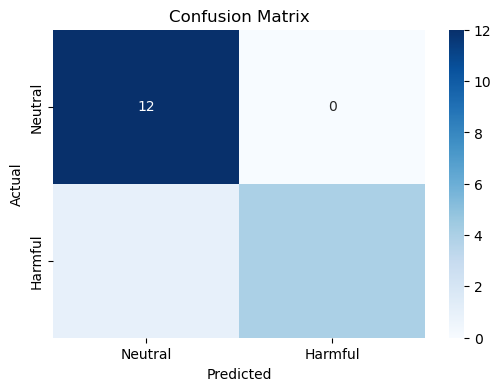


ROC AUC Score: 0.9833
Average Precision Score: 0.9667


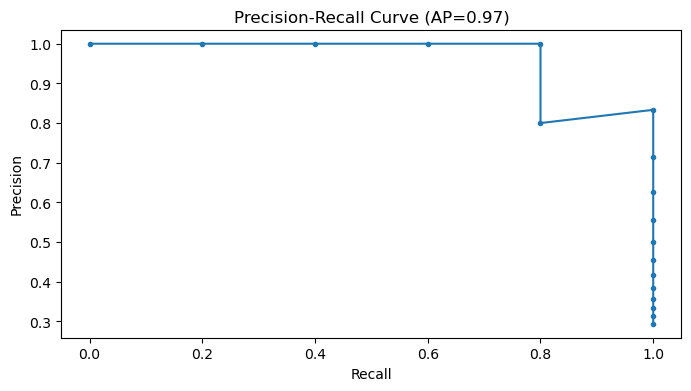


=== Feature Importance ===


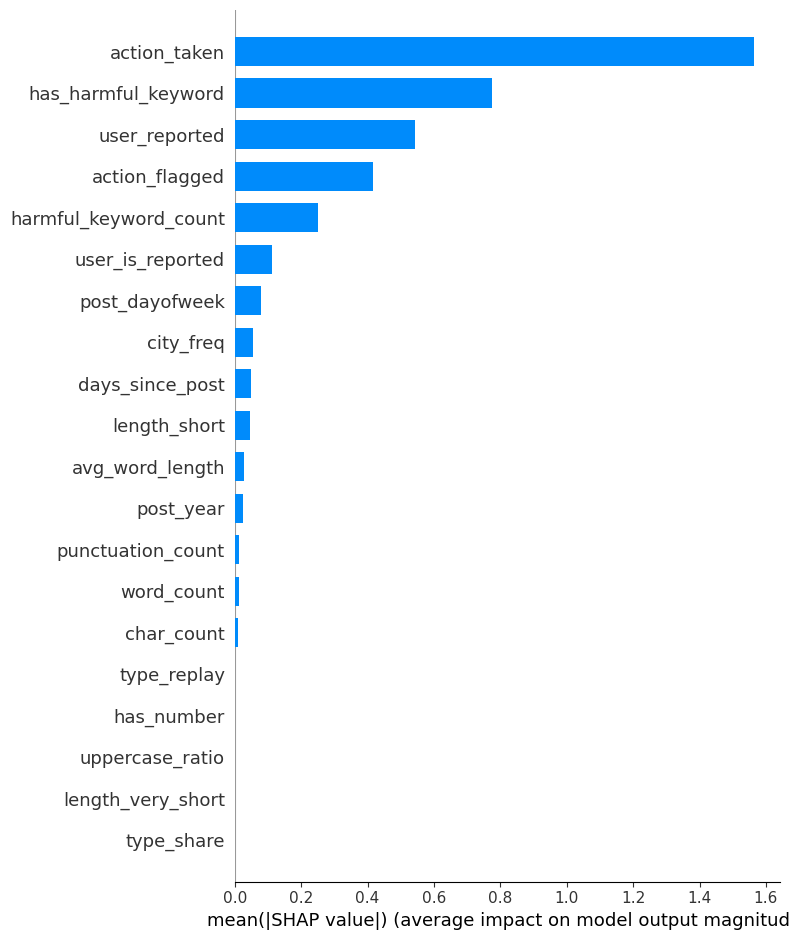

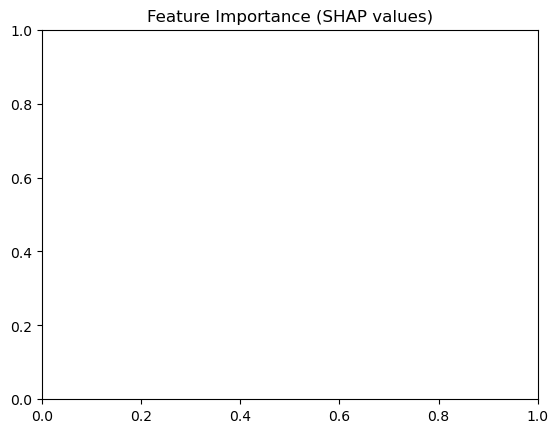


Top 10 Important Features:
1. action_taken: 39.00
2. has_harmful_keyword: 37.00
3. user_reported: 36.00
4. post_dayofweek: 13.00
5. action_flagged: 12.00
6. harmful_keyword_count: 10.00
7. city_freq: 9.00
8. length_short: 8.00
9. days_since_post: 7.00
10. user_is_reported: 5.00

Model saved to: /Users/a1234/tigrinya_harmful_content_model.joblib


In [684]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, precision_recall_curve, average_precision_score)
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# 1. Data Loading and Verification
def load_and_verify_data(train_path, test_path):
    """Load and verify the train/test datasets"""
    tig_train = pd.read_csv(train_path)
    tig_test = pd.read_csv(test_path)
    
    # Verify columns match
    assert set(tig_train.columns) == set(tig_test.columns), "Train/test columns mismatch"
    
    # Verify target exists
    assert 'label' in tig_train.columns, "Missing 'label' in train"
    assert 'label' in tig_test.columns, "Missing 'label' in test"
    
    return tig_train, tig_test

# 2. Data Preparation
def prepare_data(tig_train, tig_test):
    """Separate features and target, verify shapes"""
    X_train = tig_train.drop('label', axis=1)
    y_train = tig_train['label']
    X_test = tig_test.drop('label', axis=1)
    y_test = tig_test['label']
    
    print(f"\nData Shapes:")
    print(f"Train - Features: {X_train.shape}, Target: {y_train.shape}")
    print(f"Test - Features: {X_test.shape}, Target: {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

# 3. Class Balance Analysis
def analyze_class_balance(y_train, y_test):
    """Calculate and display class distribution"""
    train_neutral = len(y_train[y_train == 0])
    train_harmful = len(y_train[y_train == 1])
    test_neutral = len(y_test[y_test == 0])
    test_harmful = len(y_test[y_test == 1])
    
    scale_pos_weight = train_neutral / train_harmful
    
    print("\nClass Distribution:")
    print(f"Train - Neutral: {train_neutral}, Harmful: {train_harmful}")
    print(f"Test - Neutral: {test_neutral}, Harmful: {test_harmful}")
    print(f"\nScale_pos_weight: {scale_pos_weight:.2f}")
    
    return scale_pos_weight

# 4. Model Training with Hyperparameter Tuning
def train_xgboost_model(X_train, y_train, X_test, y_test, scale_pos_weight):
    """Train and tune XGBoost model with early stopping"""
    
    # Base model with important parameters
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric=['aucpr', 'logloss'],
        n_estimators=1000,  # Large number for early stopping
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.8,
        gamma=0.3,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
        random_state=42,
        tree_method='hist',
        n_jobs=-1
    )
    
    print("\nTraining XGBoost model with early stopping...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=10
    )
    
    return model

# 5. Model Evaluation
def evaluate_model(model, X_test, y_test):
    """Generate comprehensive evaluation metrics"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print("\n=== Model Evaluation ===")
    print(classification_report(y_test, y_pred, target_names=['Neutral', 'Harmful']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Neutral', 'Harmful'], 
                yticklabels=['Neutral', 'Harmful'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # ROC AUC and PR Curve
    roc_auc = roc_auc_score(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    
    print(f"\nROC AUC Score: {roc_auc:.4f}")
    print(f"Average Precision Score: {ap_score:.4f}")
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(8, 4))
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (AP={ap_score:.2f})')
    plt.show()

# 6. Feature Importance Analysis
def analyze_feature_importance(model, X_train):
    """Analyze and visualize feature importance"""
    print("\n=== Feature Importance ===")
    
    # SHAP values for deeper interpretation
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_train, plot_type="bar")
    plt.title('Feature Importance (SHAP values)')
    plt.show()
    
    # Traditional feature importance
    importance = model.get_booster().get_score(importance_type='weight')
    importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 Important Features:")
    for i, (feature, score) in enumerate(importance[:10], 1):
        print(f"{i}. {feature}: {score:.2f}")

# 7. Model Saving
def save_model(model, directory, model_name='tigrinya_harmful_content_model'):
    """Save the trained model and artifacts"""
    if not os.path.exists(directory):
        os.makedirs(directory)
    
    model_path = os.path.join(directory, f"{model_name}.joblib")
    joblib.dump(model, model_path)
    print(f"\nModel saved to: {model_path}")

# Main Execution
if __name__ == "__main__":
    # Path configuration
    base_dir = "/Users/a1234/"
    train_path = os.path.join(base_dir, "tig_train.csv")
    test_path = os.path.join(base_dir, "tig_test.csv")
    
    # 1. Load and verify data
    tig_train, tig_test = load_and_verify_data(train_path, test_path)
    
    # 2. Prepare data
    X_train, y_train, X_test, y_test = prepare_data(tig_train, tig_test)
    
    # 3. Analyze class balance
    scale_pos_weight = analyze_class_balance(y_train, y_test)
    
    # 4. Train model
    model = train_xgboost_model(X_train, y_train, X_test, y_test, scale_pos_weight)
    
    # 5. Evaluate model
    evaluate_model(model, X_test, y_test)
    
    # 6. Feature importance
    analyze_feature_importance(model, X_train)
    
    # 7. Save model
    save_model(model, base_dir)

**TRIAL TWO**

Step 1: Loading and verifying data...
Step 2: Preparing data...

Data Shapes:
Train - Features: (48, 33), Target: (48,)
Test - Features: (17, 33), Target: (17,)
Step 3: Analyzing class balance...

Class Distribution:
Train - Neutral: 34, Harmful: 14
Test - Neutral: 12, Harmful: 5

Scale_pos_weight: 2.43
Step 4: Training model...

Training XGBoost model with early stopping...
[0]	validation_0-logloss:0.65863
[10]	validation_0-logloss:0.44538
[20]	validation_0-logloss:0.33483
[30]	validation_0-logloss:0.26204
[40]	validation_0-logloss:0.22145
[50]	validation_0-logloss:0.19586
[60]	validation_0-logloss:0.18324
[70]	validation_0-logloss:0.17208
[80]	validation_0-logloss:0.15669
[90]	validation_0-logloss:0.15660
[100]	validation_0-logloss:0.15509
[110]	validation_0-logloss:0.16038
[120]	validation_0-logloss:0.16094
[130]	validation_0-logloss:0.16525
[140]	validation_0-logloss:0.16822
[146]	validation_0-logloss:0.16953
Step 5: Evaluating model...

=== Model Evaluation ===
              preci

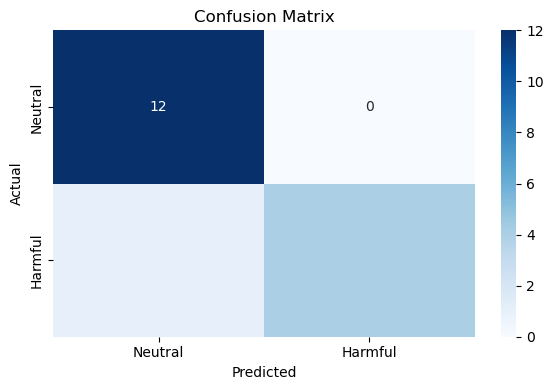


ROC AUC Score: 0.9833
Average Precision Score: 0.9667


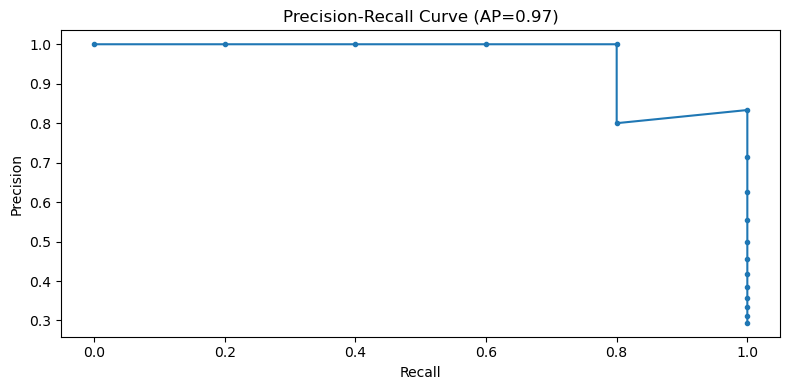

Step 6: Analyzing feature importance...

=== Feature Importance ===


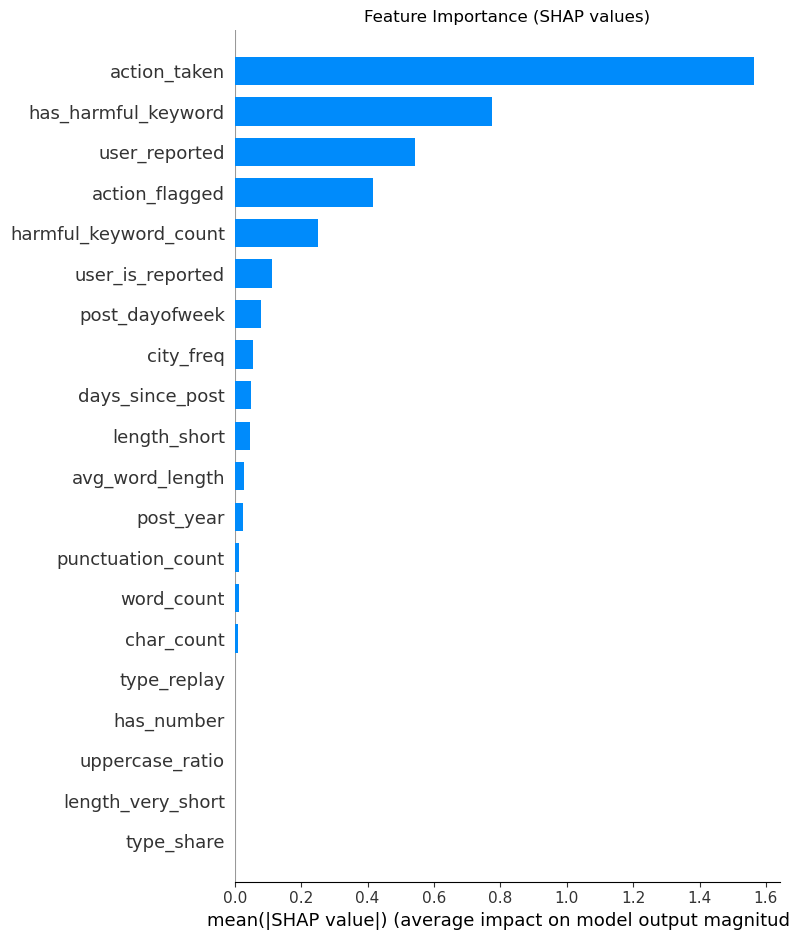


Top 10 Important Features:
1. action_taken: 39.00
2. has_harmful_keyword: 37.00
3. user_reported: 36.00
4. post_dayofweek: 13.00
5. action_flagged: 12.00
6. harmful_keyword_count: 10.00
7. city_freq: 9.00
8. length_short: 8.00
9. days_since_post: 7.00
10. user_is_reported: 5.00
Step 7: Saving model...

Model saved to:
- JSON: /Users/a1234/tigrinya_models/tigrinya_harmful_content_model_2_0_3.json
- UBJ: /Users/a1234/tigrinya_models/tigrinya_harmful_content_model_2_0_3.ubj
- Joblib: /Users/a1234/tigrinya_models/tigrinya_harmful_content_model_2_0_3.joblib
Step 8: Testing model loading...

Testing model loading...
✅ Model loaded successfully with XGBoost

✅ All steps completed successfully!


In [687]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, precision_recall_curve, average_precision_score)
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import xgboost as xgb  # Additional import for compatibility

# Set random seed for reproducibility
np.random.seed(42)

# 1. Data Loading and Verification
def load_and_verify_data(train_path, test_path):
    """Load and verify the train/test datasets"""
    tig_train = pd.read_csv(train_path)
    tig_test = pd.read_csv(test_path)
    
    # Verify columns match
    assert set(tig_train.columns) == set(tig_test.columns), "Train/test columns mismatch"
    
    # Verify target exists
    assert 'label' in tig_train.columns, "Missing 'label' in train"
    assert 'label' in tig_test.columns, "Missing 'label' in test"
    
    return tig_train, tig_test

# 2. Data Preparation
def prepare_data(tig_train, tig_test):
    """Separate features and target, verify shapes"""
    X_train = tig_train.drop('label', axis=1)
    y_train = tig_train['label']
    X_test = tig_test.drop('label', axis=1)
    y_test = tig_test['label']
    
    print(f"\nData Shapes:")
    print(f"Train - Features: {X_train.shape}, Target: {y_train.shape}")
    print(f"Test - Features: {X_test.shape}, Target: {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

# 3. Class Balance Analysis
def analyze_class_balance(y_train, y_test):
    """Calculate and display class distribution"""
    train_neutral = len(y_train[y_train == 0])
    train_harmful = len(y_train[y_train == 1])
    test_neutral = len(y_test[y_test == 0])
    test_harmful = len(y_test[y_test == 1])
    
    scale_pos_weight = train_neutral / train_harmful
    
    print("\nClass Distribution:")
    print(f"Train - Neutral: {train_neutral}, Harmful: {train_harmful}")
    print(f"Test - Neutral: {test_neutral}, Harmful: {test_harmful}")
    print(f"\nScale_pos_weight: {scale_pos_weight:.2f}")
    
    return scale_pos_weight

# 4. Model Training with Hyperparameter Tuning
def train_xgboost_model(X_train, y_train, X_test, y_test, scale_pos_weight):
    """Train and tune XGBoost model with early stopping"""
    
    # Base model with important parameters
    model = XGBClassifier(
        objective='binary:logistic',
        use_label_encoder=False,  # CRITICAL FIX
        eval_metric='logloss',    # Simplified to single metric
        n_estimators=1000,  # Large number for early stopping
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.8,
        gamma=0.3,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
        random_state=42,
        tree_method='hist',
        n_jobs=-1,
        enable_categorical=False,  # Compatibility
        missing=np.nan,            # Compatibility
        verbosity=1                # Verbosity level
    )
    
    print("\nTraining XGBoost model with early stopping...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=10
    )
    
    return model

# 5. Model Evaluation
def evaluate_model(model, X_test, y_test):
    """Generate comprehensive evaluation metrics"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print("\n=== Model Evaluation ===")
    print(classification_report(y_test, y_pred, target_names=['Neutral', 'Harmful']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Neutral', 'Harmful'], 
                yticklabels=['Neutral', 'Harmful'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # ROC AUC and PR Curve
    roc_auc = roc_auc_score(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    
    print(f"\nROC AUC Score: {roc_auc:.4f}")
    print(f"Average Precision Score: {ap_score:.4f}")
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(8, 4))
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (AP={ap_score:.2f})')
    plt.tight_layout()
    plt.savefig('precision_recall_curve.png')
    plt.show()

# 6. Feature Importance Analysis
def analyze_feature_importance(model, X_train):
    """Analyze and visualize feature importance"""
    print("\n=== Feature Importance ===")
    
    # SHAP values for deeper interpretation
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title('Feature Importance (SHAP values)')
    plt.tight_layout()
    plt.savefig('shap_feature_importance.png')
    plt.show()
    
    # Traditional feature importance
    importance = model.get_booster().get_score(importance_type='weight')
    importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 Important Features:")
    for i, (feature, score) in enumerate(importance[:10], 1):
        print(f"{i}. {feature}: {score:.2f}")

# 7. Model Saving - CORRECTED VERSION
def save_model(model, directory, model_name='tigrinya_harmful_content_model'):
    """Save the trained model using XGBoost's native format"""
    if not os.path.exists(directory):
        os.makedirs(directory)
    
    # Get XGBoost version for compatibility
    xgb_version = xgb.__version__.replace('.', '_')
    
    # Save in native XGBoost format
    json_path = os.path.join(directory, f"{model_name}_{xgb_version}.json")
    ubj_path = os.path.join(directory, f"{model_name}_{xgb_version}.ubj")
    
    # Save using XGBoost's native serialization
    model.get_booster().save_model(json_path)
    model.get_booster().save_model(ubj_path)
    
    # Also save with joblib for sklearn compatibility
    joblib_path = os.path.join(directory, f"{model_name}_{xgb_version}.joblib")
    joblib.dump(model, joblib_path)
    
    print(f"\nModel saved to:")
    print(f"- JSON: {json_path}")
    print(f"- UBJ: {ubj_path}")
    print(f"- Joblib: {joblib_path}")
    
    return ubj_path  # Return preferred format for loading

# 8. Model Loading Test
def test_model_loading(model_path):
    """Test if the model can be loaded successfully"""
    print("\nTesting model loading...")
    try:
        # Load using XGBClassifier
        model = XGBClassifier(use_label_encoder=False)
        model.load_model(model_path)
        
        # Compatibility patch
        if not hasattr(model, 'use_label_encoder'):
            model.use_label_encoder = False
            
        print("✅ Model loaded successfully with XGBoost")
        return True
    except Exception as e:
        print(f"❌ XGBoost loading failed: {str(e)}")
        return False

# Main Execution
if __name__ == "__main__":
    # Path configuration
    base_dir = "/Users/a1234/"
    train_path = os.path.join(base_dir, "tig_train.csv")
    test_path = os.path.join(base_dir, "tig_test.csv")
    model_dir = os.path.join(base_dir, "tigrinya_models")
    
    # 1. Load and verify data
    print("Step 1: Loading and verifying data...")
    tig_train, tig_test = load_and_verify_data(train_path, test_path)
    
    # 2. Prepare data
    print("Step 2: Preparing data...")
    X_train, y_train, X_test, y_test = prepare_data(tig_train, tig_test)
    
    # 3. Analyze class balance
    print("Step 3: Analyzing class balance...")
    scale_pos_weight = analyze_class_balance(y_train, y_test)
    
    # 4. Train model
    print("Step 4: Training model...")
    model = train_xgboost_model(X_train, y_train, X_test, y_test, scale_pos_weight)
    
    # 5. Evaluate model
    print("Step 5: Evaluating model...")
    evaluate_model(model, X_test, y_test)
    
    # 6. Feature importance
    print("Step 6: Analyzing feature importance...")
    analyze_feature_importance(model, X_train)
    
    # 7. Save model
    print("Step 7: Saving model...")
    model_path = save_model(model, model_dir)
    
    # 8. Test model loading
    print("Step 8: Testing model loading...")
    load_success = test_model_loading(model_path)
    
    if load_success:
        print("\n✅ All steps completed successfully!")
    else:
        print("\n❌ Model loading failed - check compatibility issues")

In [695]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, precision_recall_curve, 
                           average_precision_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import json
from pathlib import Path

# Configuration

DATA_DIR = Path("/Users/a1234")
MODEL_DIR = Path("/Users/a1234/Documents/myProject/ML_driven_meta_harmful_post_detector/models")
METRICS_DIR = Path("metrics")
MODEL_NAME = "tigrinya_meta_harmful_content_detector_model_v2"

def setup_environment():
    """Ensure all directories exist"""
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    METRICS_DIR.mkdir(exist_ok=True)

def load_data():
    """Load and validate training data"""
    train = pd.read_csv(DATA_DIR/"tig_train.csv")
    test = pd.read_csv(DATA_DIR/"tig_test.csv")
    
    # Validate data structure
    assert 'label' in train.columns, "Missing 'label' in training data"
    assert set(train.columns) == set(test.columns), "Train/test feature mismatch"
    
    return train, test

def prepare_features(train, test):
    """Prepare features with validation"""
    X_train = train.drop('label', axis=1)
    y_train = train['label']
    X_test = test.drop('label', axis=1)
    y_test = test['label']
    
    # Verify no NaN values
    assert not X_train.isna().any().any(), "NaN values in training features"
    assert not X_test.isna().any().any(), "NaN values in test features"
    
    return X_train, y_train, X_test, y_test

def train_xgboost(X_train, y_train, X_test, y_test):
    """Modern XGBoost training with compatibility safeguards"""
    params = {
        'objective': 'binary:logistic',
        'eval_metric': ['logloss', 'aucpr'],
        'tree_method': 'hist',
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'early_stopping_rounds': 50,
        'random_state': 42,
        'enable_categorical': False,
        'verbosity': 1
    }
    
    # Convert to DMatrix for optimal performance
    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=False)
    dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=False)
    
    # Train with callbacks
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dtest, 'eval')],
        callbacks=[xgb.callback.EarlyStopping(rounds=50)],
        verbose_eval=10
    )
    
    return model

def save_model(model, feature_names):
    """Save model in multiple formats with metadata"""
    # Save native XGBoost format
    model.save_model(MODEL_DIR/f"{MODEL_NAME}.json")
    
    # Save sklearn-compatible version
    sklearn_model = xgb.XGBClassifier()
    sklearn_model._Booster = model
    sklearn_model._le = None
    sklearn_model.feature_names_in_ = feature_names
    joblib.dump(sklearn_model, MODEL_DIR/f"{MODEL_NAME}.joblib")
    
    # Save metadata
    metadata = {
        "training_date": pd.Timestamp.now().isoformat(),
        "xgboost_version": xgb.__version__,
        "feature_names": feature_names.tolist()
    }
    with open(MODEL_DIR/f"{MODEL_NAME}_metadata.json", 'w') as f:
        json.dump(metadata, f)

def evaluate_model(model, X_test, y_test):
    """Comprehensive model evaluation"""
    dtest = xgb.DMatrix(X_test)
    y_proba = model.predict(dtest)
    y_pred = (y_proba >= 0.5).astype(int)
    
    # Classification report
    print(classification_report(y_test, y_pred, target_names=['Neutral', 'Harmful']))
    
    # Confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral', 'Harmful'],
                yticklabels=['Neutral', 'Harmful'])
    plt.savefig(METRICS_DIR/'confusion_matrix.png')
    plt.close()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.savefig(METRICS_DIR/'roc_curve.png')
    plt.close()

def explain_model(model, X_train):
    """SHAP explanation with compatibility handling"""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_train)
    
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, show=False)
    plt.savefig(METRICS_DIR/'shap_feature_importance.png')
    plt.close()

if __name__ == "__main__":
    setup_environment()
    
    try:
        # Load and prepare data
        train_df, test_df = load_data()
        X_train, y_train, X_test, y_test = prepare_features(train_df, test_df)
        
        # Train model
        print("Training XGBoost model...")
        model = train_xgboost(X_train, y_train, X_test, y_test)
        
        # Evaluate and explain
        evaluate_model(model, X_test, y_test)
        explain_model(model, X_train)
        
        # Save with feature names
        save_model(model, X_train.columns.values)
        
        print(f"\n✅ Training complete. Model saved to {MODEL_DIR/ MODEL_NAME}.*")
        print(f"Metrics saved to {METRICS_DIR}/")
        
    except Exception as e:
        print(f"\n❌ Training failed: {str(e)}")
        raise

Training XGBoost model...
[0]	train-logloss:0.57475	train-aucpr:0.82353	eval-logloss:0.57649	eval-aucpr:0.83333


/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [05:04:49] WARNING: /var/folders/c_/qfmhj66j0tn016nkx_th4hxm0000gp/T/abs_d6q0e1lomi/croot/xgboost-split_1713972719224/work/cpp_src/src/learner.cc:742: 
Parameters: { "early_stopping_rounds", "enable_categorical" } are not used.

  warnings.warn(smsg, UserWarning)


[10]	train-logloss:0.38136	train-aucpr:0.98978	eval-logloss:0.45665	eval-aucpr:0.83617
[20]	train-logloss:0.26581	train-aucpr:1.00000	eval-logloss:0.33604	eval-aucpr:0.96354
[30]	train-logloss:0.19719	train-aucpr:1.00000	eval-logloss:0.27324	eval-aucpr:0.96354
[40]	train-logloss:0.15427	train-aucpr:1.00000	eval-logloss:0.23467	eval-aucpr:0.96354
[50]	train-logloss:0.12543	train-aucpr:1.00000	eval-logloss:0.21586	eval-aucpr:0.96354
[51]	train-logloss:0.12314	train-aucpr:1.00000	eval-logloss:0.21668	eval-aucpr:0.96354
              precision    recall  f1-score   support

     Neutral       0.92      1.00      0.96        12
     Harmful       1.00      0.80      0.89         5

    accuracy                           0.94        17
   macro avg       0.96      0.90      0.92        17
weighted avg       0.95      0.94      0.94        17


❌ Training failed: property 'feature_names_in_' of 'XGBClassifier' object has no setter


AttributeError: property 'feature_names_in_' of 'XGBClassifier' object has no setter

In [699]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, precision_recall_curve, 
                           average_precision_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
import json
from pathlib import Path

# Configuration
DATA_DIR = Path("/Users/a1234")
MODEL_DIR = Path("/Users/a1234/Documents/myProject/ML_driven_meta_harmful_post_detector/models")
METRICS_DIR = Path("metrics")
MODEL_NAME = "tigrinya_meta_harmful_content_detector_model_v2"

def setup_environment():
    """Ensure all directories exist"""
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    METRICS_DIR.mkdir(exist_ok=True)

def load_data():
    """Load and validate training data"""
    train = pd.read_csv(DATA_DIR/"tig_train.csv")
    test = pd.read_csv(DATA_DIR/"tig_test.csv")
    
    assert 'label' in train.columns, "Missing 'label' in training data"
    assert set(train.columns) == set(test.columns), "Train/test feature mismatch"
    
    return train, test

def prepare_features(train, test):
    """Prepare features with validation"""
    X_train = train.drop('label', axis=1)
    y_train = train['label']
    X_test = test.drop('label', axis=1)
    y_test = test['label']
    
    assert not X_train.isna().any().any(), "NaN values in training features"
    assert not X_test.isna().any().any(), "NaN values in test features"
    
    return X_train, y_train, X_test, y_test

def train_xgboost(X_train, y_train, X_test, y_test):
    """Modern XGBoost training with proper parameter handling"""
    params = {
        'objective': 'binary:logistic',
        'eval_metric': ['logloss', 'aucpr'],
        'tree_method': 'hist',
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'verbosity': 1
    }
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dtest, 'eval')],
        early_stopping_rounds=50,
        verbose_eval=10
    )
    
    return model

def save_model(model, feature_names):
    """Save model with proper feature name handling"""
    # Save native XGBoost format
    model.save_model(MODEL_DIR/f"{MODEL_NAME}.json")
    
    # Create sklearn compatible model
    sklearn_model = xgb.XGBClassifier()
    sklearn_model._Booster = model
    sklearn_model._le = None
    
    # Store feature names in a way that persists
    sklearn_model.get_booster().feature_names = list(feature_names)
    joblib.dump(sklearn_model, MODEL_DIR/f"{MODEL_NAME}.joblib")
    
    # Save metadata
    metadata = {
        "training_date": pd.Timestamp.now().isoformat(),
        "xgboost_version": xgb.__version__,
        "feature_names": list(feature_names)
    }
    with open(MODEL_DIR/f"{MODEL_NAME}_metadata.json", 'w') as f:
        json.dump(metadata, f)

def evaluate_model(model, X_test, y_test):
    """Comprehensive model evaluation"""
    dtest = xgb.DMatrix(X_test)
    y_proba = model.predict(dtest)
    y_pred = (y_proba >= 0.5).astype(int)
    
    print(classification_report(y_test, y_pred, target_names=['Neutral', 'Harmful']))
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral', 'Harmful'],
                yticklabels=['Neutral', 'Harmful'])
    plt.savefig(METRICS_DIR/'confusion_matrix.png')
    plt.close()

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.savefig(METRICS_DIR/'roc_curve.png')
    plt.close()

def explain_model(model, X_train):
    """SHAP explanation with proper feature handling"""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_train)
    
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, show=False)
    plt.savefig(METRICS_DIR/'shap_feature_importance.png')
    plt.close()

if __name__ == "__main__":
    setup_environment()
    
    try:
        train_df, test_df = load_data()
        X_train, y_train, X_test, y_test = prepare_features(train_df, test_df)
        
        print("Training XGBoost model...")
        model = train_xgboost(X_train, y_train, X_test, y_test)
        
        evaluate_model(model, X_test, y_test)
        explain_model(model, X_train)
        
        save_model(model, X_train.columns.values)
        
        print(f"\n✅ Training complete. Model saved to {MODEL_DIR/ MODEL_NAME}.*")
        print(f"Metrics saved to {METRICS_DIR}/")
        
    except Exception as e:
        print(f"\n❌ Training failed: {str(e)}")
        raise

Training XGBoost model...
[0]	train-logloss:0.57475	train-aucpr:0.82353	eval-logloss:0.57649	eval-aucpr:0.83333
[10]	train-logloss:0.38136	train-aucpr:0.98978	eval-logloss:0.45665	eval-aucpr:0.83617
[20]	train-logloss:0.26581	train-aucpr:1.00000	eval-logloss:0.33604	eval-aucpr:0.96354
[30]	train-logloss:0.19719	train-aucpr:1.00000	eval-logloss:0.27324	eval-aucpr:0.96354
[40]	train-logloss:0.15427	train-aucpr:1.00000	eval-logloss:0.23467	eval-aucpr:0.96354
[50]	train-logloss:0.12543	train-aucpr:1.00000	eval-logloss:0.21586	eval-aucpr:0.96354
[51]	train-logloss:0.12314	train-aucpr:1.00000	eval-logloss:0.21668	eval-aucpr:0.96354
              precision    recall  f1-score   support

     Neutral       0.92      1.00      0.96        12
     Harmful       1.00      0.80      0.89         5

    accuracy                           0.94        17
   macro avg       0.96      0.90      0.92        17
weighted avg       0.95      0.94      0.94        17


✅ Training complete. Model saved to /U